# Análisis Exploratorio de Datos (EDA): Bienestar Laboral Académico (Austria y Rep. Checa)

Este notebook realiza un análisis exploratorio detallado sobre el conjunto de datos de bienestar laboral de personal académico en Austria y la República Checa. Los objetivos son:
1.  **Limpiar y preprocesar** los datos (manejo de faltantes con k-NN/moda, codificación de etiquetas categóricas, manejo de outliers).
2.  Realizar **análisis univariado** para comprender la distribución de cada variable.
3.  Realizar **análisis multivariado** para explorar relaciones entre variables (correlaciones).
4.  Investigar **disparidades y sesgos** mediante estadísticas agrupadas y visualizaciones comparativas por país, género, edad, tipo de institución y área de estudio.

El análisis se enfoca en la exploración y descripción, preparando el terreno para futuros modelos estadísticos.

## 1. Configuración Inicial: Importación de Bibliotecas

In [10]:
# Manipulación de Datos
import pandas as pd
import numpy as np

# Visualización de Datos
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# Preprocesamiento
from sklearn.impute import KNNImputer

# Utilidades de Visualización y Warnings
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore') # Suprimir warnings para limpieza de output

# Configuraciones de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Carga de Datos

In [11]:
# Cargar el dataset desde el archivo CSV
try:
    df_raw = pd.read_csv('labour_well_being_data.csv')
    print("Datos cargados exitosamente.")
    display(df_raw.head())
except FileNotFoundError:
    print("Error: El archivo 'labour_well_being_data.csv' no se encontró. Verifica la ruta.")
    df_raw = pd.DataFrame() # Crear DataFrame vacío para evitar errores posteriores

Datos cargados exitosamente.


,Country,Version,Gender,Age,Marital_Status,Care_Responsibilities,HEI_Type,Faculty_Subject_Area,Employment_Contract_Duration,HEI_Employment_Hours,...,Research_Hours,Funded_Research_Activities,Administrative_Activities,Performance_Pressure,Perceived_Autonomy,Quality_of_Leadership,Sense_of_Community,Job_Satisfaction,Burnout,Current_Position
0,2,4,2.0,28.0,3.0,1.0,1.0,1.0,2.0,40.0,...,29.0,1.0,15.0,1.0,1.833333,3.00,2.666667,2.2,4.00,3.0
1,2,4,1.0,33.0,2.0,1.0,1.0,3.0,3.0,40.0,...,30.0,5.0,10.0,5.0,1.500000,2.00,1.666667,2.4,4.00,3.0
2,2,4,2.0,32.0,3.0,1.0,3.0,5.0,4.0,1.5,...,NaN,NaN,NaN,4.0,4.666667,5.00,5.000000,5.0,4.25,3.0
3,2,4,2.0,30.0,2.0,1.0,1.0,5.0,1.0,40.0,...,10.0,NaN,10.0,1.0,3.833333,2.00,3.000000,2.8,3.25,3.0
4,2,4,1.0,39.0,2.0,2.0,1.0,5.0,2.0,40.0,...,20.0,10.0,3.0,5.0,3.166667,3.75,3.000000,2.6,4.50,4.0


## 3. Exploración Inicial de Datos

In [12]:
if not df_raw.empty:
    print(f"Dimensiones del DataFrame: {df_raw.shape}")
    print("\nInformación general y tipos de dato:")
    df_raw.info()

    print("\nResumen de valores faltantes:")
    missing_values = df_raw.isnull().sum()
    missing_percentage = (missing_values / len(df_raw)) * 100
    missing_info = pd.DataFrame({'Count': missing_values, 'Percentage': missing_percentage})
    display(missing_info[missing_info['Count'] > 0].sort_values(by='Count', ascending=False))

    print("\nEstadísticas descriptivas iniciales (variables numéricas):")
    display(df_raw.describe())
else:
    print("DataFrame vacío, exploración inicial omitida.")

Dimensiones del DataFrame: (2748, 36)

Información general y tipos de dato:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2748 non-null   int64  
 1   Version                       2748 non-null   int64  
 2   Gender                        2748 non-null   float64
 3   Age                           2748 non-null   float64
 4   Marital_Status                2720 non-null   float64
 5   Care_Responsibilities         2729 non-null   float64
 6   HEI_Type                      2748 non-null   float64
 7   Faculty_Subject_Area          2720 non-null   float64
 8   Employment_Contract_Duration  2745 non-null   float64
 9   HEI_Employment_Hours          2748 non-null   float64
 10  HEI_Actual_Weekly_Hours       2748 non-null   float64
 11  Effort_Level                  2748 non-null  

,Count,Percentage
Highest_Education_Level,2210,80.422125
Career_Length_CZ,2208,80.349345
Job_Category,2157,78.493450
Funded_Research_Activities,757,27.547307
Research_Hours,669,24.344978
Administrative_Activities,667,24.272198
Teaching_Hours,647,23.544396
Perceived_Autonomy,48,1.746725
Marital_Status,28,1.018923
Faculty_Subject_Area,28,1.018923



Estadísticas descriptivas iniciales (variables numéricas):


,Country,Version,Gender,Age,Marital_Status,Care_Responsibilities,HEI_Type,Faculty_Subject_Area,Employment_Contract_Duration,HEI_Employment_Hours,...,Research_Hours,Funded_Research_Activities,Administrative_Activities,Performance_Pressure,Perceived_Autonomy,Quality_of_Leadership,Sense_of_Community,Job_Satisfaction,Burnout,Current_Position
count,2748.000000,2748.000000,2748.000000,2748.000000,2720.000000,2729.000000,2748.000000,2720.000000,2745.000000,2748.000000,...,2079.000000,1991.000000,2081.000000,2740.000000,2700.000000,2732.000000,2747.000000,2745.000000,2742.000000,2748.000000
mean,1.516376,1.627729,1.600801,42.759825,1.775368,1.497618,2.751456,4.898162,1.844444,35.226019,...,14.278114,5.084103,7.345915,3.619708,3.225864,3.258907,3.933018,3.249101,4.242858,5.186681
std,0.499823,0.654343,0.499391,10.892490,0.932781,0.639669,1.817406,3.032543,1.226912,9.505506,...,11.056519,6.060637,7.482553,1.058655,0.865618,1.154939,0.944119,0.818893,1.271337,3.451217
min,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.500000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,1.000000,34.000000,1.000000,1.000000,1.000000,2.000000,1.000000,30.000000,...,5.000000,0.000000,2.000000,3.000000,2.666667,2.500000,3.333333,2.600000,3.250000,2.000000
50%,2.000000,2.000000,2.000000,42.000000,2.000000,1.000000,3.000000,5.000000,1.000000,40.000000,...,10.000000,3.000000,5.000000,4.000000,3.333333,3.250000,4.000000,3.200000,4.000000,4.000000
75%,2.000000,2.000000,2.000000,50.000000,2.000000,2.000000,4.000000,7.000000,2.000000,40.000000,...,20.000000,8.000000,10.000000,4.000000,3.833333,4.250000,4.666667,3.800000,5.000000,8.000000
max,2.000000,4.000000,3.000000,84.000000,6.000000,4.000000,8.000000,13.000000,7.000000,80.000000,...,75.000000,50.000000,80.000000,5.000000,5.000000,5.000000,5.000000,5.000000,7.000000,13.000000


## 4. Preprocesamiento de Datos

En esta sección, realizaremos los siguientes pasos:
1.  **Codificación de Etiquetas:** Convertir variables categóricas numéricas a etiquetas de texto legibles.
2.  **Imputación de Valores Faltantes:** Usar k-NN para variables numéricas y moda para categóricas.
3.  **Manejo de Outliers:** Aplicar el método IQR para limitar valores extremos en variables numéricas.

### 4.1 Codificación de Etiquetas para Variables Categóricas

In [13]:
if not df_raw.empty:
    df = df_raw.copy() # Trabajar sobre una copia

    # --- Definir Mapeos basados en el Data Dictionary y Cuestionario ---
    country_map = {1: 'Austria', 2: 'Czech Republic'}
    gender_map = {1: 'Male', 2: 'Female', 3: 'Other'}
    marital_map = {1: 'Married/Registered Partnership', 2: 'In a relationship (unmarried)',
                   3: 'Single', 4: 'Divorced', 5: 'Widowed'}
    care_map = {1: 'No', 2: 'Care for underage children', 3: 'Care for dependent relatives'}
    hei_type_map = {1: 'Public HEI', 2: 'Private HEI', 3: 'State HEI'}
    faculty_map = {
        1: 'Natural sciences', 2: 'Technical sciences', 3: 'Agricultural/forestry/veterinary',
        4: 'Healthcare/medical/pharmaceutical', 5: 'Humanities/social sciences',
        6: 'Economic sciences', 7: 'Law', 8: 'Pedagogy/teacher training',
        9: 'Culture/art', 10: 'Sport sciences', 11: 'Unspecified/cannot be categorised',
        12: 'Other_Faculty'
    }
    contract_map = {
        1: 'Permanent', 2: 'Fixed-term (permanent prospects)',
        3: 'Fixed-term (no permanent prospects)', 4: 'Casual/hourly', 5: 'Other_Contract'
    }
    leadership_map = {1: 'No', 2: 'Yes (Institution/Faculty/Dept)', 3: 'Yes (Research Team)'}
    # Policy_Influence es ordinal, mantener numérico por ahora
    other_job_map = {
        1: 'No', 2: 'Yes (Public Sector)', 3: 'Yes (Private Sector)',
        4: 'Yes (Non-profit)', 5: 'Yes (Self-employed)',
        6: 'Yes (Multiple Areas)', 7: 'Yes (Other_Job)'
    }
    academic_map = {1: 'Non-academic', 2: 'Academic'}
    position_map = { # Mapeo para Current_Position (Q15)
        1: 'Lecturer', 2: 'Assistant', 3: 'Assistant professor', 4: 'Docent',
        5: 'Professor', 6: 'Researcher', 7: 'Externist', 8: 'Other_Position'
        # El código 0 podría ser para 'Non-academic', verificar
    }
    job_cat_map = { # Mapeo para Job_Category (Q16, Non-academic)
        1: 'Dept/manager assistant', 2: 'Lab technician', 3: 'Librarian/archivist',
        4: 'Facility management', 5: 'ICT', 6: 'Student support',
        7: 'Economics/finance/HR', 8: 'Project management', 9: 'Legal/control',
        10: 'Marketing/PR', 11: 'Science/knowledge transfer', 12: 'Foreign affairs',
        13: 'Other administrative', 14: 'Other_JobCategory'
    }
    education_map = { # Mapeo para Highest_Education_Level (Q17, Non-academic)
        1: 'Elementary', 2: 'High school/Secondary', 3: 'Bachelor',
        4: 'Master', 5: 'Doctoral', 6: 'Other_Education'
    }

    # --- Aplicar Mapeos ---
    # Usar .get() en map para manejar valores no en el dict (mantendrá NaN o valores no mapeados)
    df['Country'] = df['Country'].map(country_map).astype('category')
    df['Gender'] = df['Gender'].map(gender_map).astype('category')
    df['Marital_Status'] = df['Marital_Status'].map(marital_map).astype('category')
    # Care_Responsibilities podría ser multi-respuesta, tratarlo con cuidado. Mapeo simple asumiendo valor único.
    df['Care_Responsibilities'] = df['Care_Responsibilities'].map(care_map).astype('category')
    df['HEI_Type'] = df['HEI_Type'].map(hei_type_map).astype('category')
    df['Faculty_Subject_Area'] = df['Faculty_Subject_Area'].map(faculty_map).astype('category')
    df['Employment_Contract_Duration'] = df['Employment_Contract_Duration'].map(contract_map).astype('category')
    df['Leadership_Position'] = df['Leadership_Position'].map(leadership_map).astype('category') # Podría ser multi-respuesta
    df['Other_Paid_Job'] = df['Other_Paid_Job'].map(other_job_map).astype('category')
    df['Academic_or_Non_Academic'] = df['Academic_or_Non_Academic'].map(academic_map).astype('category')

    # Mapeos condicionales (aplican solo a subgrupos)
    df['Current_Position_Label'] = df['Current_Position'].map(position_map).astype('category') # Nueva columna para etiqueta
    df['Job_Category_Label'] = df['Job_Category'].map(job_cat_map).astype('category') # Nueva columna para etiqueta
    df['Highest_Education_Label'] = df['Highest_Education_Level'].map(education_map).astype('category') # Nueva columna para etiqueta

    # Seleccionar columnas categóricas conceptualmente (excluyendo las numéricas que se mantendrán así)
    categorical_cols_labeled = df.select_dtypes(include=['category']).columns.tolist()

    print("Variables categóricas codificadas con etiquetas:")
    display(df[categorical_cols_labeled].head())
    print("\nTipos de datos después de la codificación de etiquetas:")
    df.info() # Verificar cambios en Dtype
else:
    print("DataFrame vacío, codificación de etiquetas omitida.")
    df = pd.DataFrame() # Asegurar que df exista

Variables categóricas codificadas con etiquetas:


,Country,Gender,Marital_Status,Care_Responsibilities,HEI_Type,Faculty_Subject_Area,Employment_Contract_Duration,Leadership_Position,Other_Paid_Job,Academic_or_Non_Academic,Current_Position_Label,Job_Category_Label,Highest_Education_Label
0,Czech Republic,Female,Single,No,Public HEI,Natural sciences,Fixed-term (permanent prospects),No,No,Academic,Assistant professor,NaN,NaN
1,Czech Republic,Male,In a relationship (unmarried),No,Public HEI,Agricultural/forestry/veterinary,Fixed-term (no permanent prospects),No,Yes (Self-employed),Academic,Assistant professor,NaN,NaN
2,Czech Republic,Female,Single,No,State HEI,Humanities/social sciences,Casual/hourly,No,Yes (Non-profit),Academic,Assistant professor,NaN,NaN
3,Czech Republic,Female,In a relationship (unmarried),No,Public HEI,Humanities/social sciences,Permanent,No,No,Academic,Assistant professor,NaN,NaN
4,Czech Republic,Male,In a relationship (unmarried),Care for underage children,Public HEI,Humanities/social sciences,Fixed-term (permanent prospects),No,No,Academic,Docent,NaN,NaN



Tipos de datos después de la codificación de etiquetas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Country                       2748 non-null   category
 1   Version                       2748 non-null   int64   
 2   Gender                        2748 non-null   category
 3   Age                           2748 non-null   float64 
 4   Marital_Status                2716 non-null   category
 5   Care_Responsibilities         2694 non-null   category
 6   HEI_Type                      1421 non-null   category
 7   Faculty_Subject_Area          2710 non-null   category
 8   Employment_Contract_Duration  2625 non-null   category
 9   HEI_Employment_Hours          2748 non-null   float64 
 10  HEI_Actual_Weekly_Hours       2748 non-null   float64 
 11  Effort_Level                  2748 non-null   float

### 4.2 Imputación de Valores Faltantes

* **Variables Numéricas:** Se utilizará `KNNImputer` (basado en k-Vecinos Más Cercanos).
* **Variables Categóricas (con etiquetas):** Se utilizará la **Moda** (valor más frecuente).

In [14]:
if not df.empty:
    # Identificar columnas numéricas y categóricas (post-etiquetado)
    numeric_cols_for_imputation = df.select_dtypes(include=np.number).columns.difference(['Version'])
    categorical_cols_for_imputation = df.select_dtypes(include=['category', 'object']).columns

    # --- Imputación Numérica con k-NN ---
    if not df[numeric_cols_for_imputation].isnull().all().all():
        print(f"Imputando {len(numeric_cols_for_imputation)} columnas numéricas con k-NN...")
        # Check if there are actually columns to impute after checking for NaNs
        cols_with_nans_numeric = df[numeric_cols_for_imputation].isnull().any()
        cols_to_impute_numeric = cols_with_nans_numeric[cols_with_nans_numeric].index

        if not cols_to_impute_numeric.empty:
            knn_imputer = KNNImputer(n_neighbors=5)
            df[cols_to_impute_numeric] = knn_imputer.fit_transform(df[cols_to_impute_numeric])
            print(f"Imputación numérica completada para {len(cols_to_impute_numeric)} columnas.")
        else:
            print("No se encontraron columnas numéricas con valores faltantes para imputar con k-NN.")

    else:
        print("No se encontraron valores faltantes en columnas numéricas o no hay columnas numéricas para imputar.")

    # --- Imputación Categórica con Moda ---
    print(f"\nImputando {len(categorical_cols_for_imputation)} columnas categóricas con la Moda...")
    imputed_categorical_count = 0
    for col in categorical_cols_for_imputation:
        if df[col].isnull().any():
            # Check if mode exists (important for columns with all NaNs initially)
            if not df[col].mode().empty:
                mode_val = df[col].mode()[0]
                df[col].fillna(mode_val, inplace=True)
                imputed_categorical_count += 1

                # Asegurarse de que el tipo sigue siendo category después de fillna
                # Esto es importante porque fillna a veces puede cambiar el dtype si todos los NaNs se rellenan
                # y el resultado es homogéneo (aunque con la moda es menos probable).
                # Forzamos que sea categórico si no lo es ya.
                if not pd.api.types.is_categorical_dtype(df[col]):
                    try:
                        # Intentar convertir a categórico explícitamente
                        df[col] = pd.Categorical(df[col])
                    except Exception as e:
                         print(f"Advertencia: No se pudo convertir la columna {col} a category después de la imputación: {e}")
            else:
                 print(f"Advertencia: No se pudo imputar la columna {col} con moda (posiblemente todos los valores son NaN).")

    print(f"Imputación categórica completada para {imputed_categorical_count} columnas.")

    # Verificar valores faltantes restantes
    print("\nValores faltantes después de la imputación:")
    missing_after = df.isnull().sum()
    display(missing_after[missing_after > 0])
else:
    print("DataFrame vacío, imputación omitida.")

Imputando 25 columnas numéricas con k-NN...
Imputación numérica completada para 14 columnas.

Imputando 13 columnas categóricas con la Moda...
Imputación categórica completada para 9 columnas.

Valores faltantes después de la imputación:


,0


### 4.3 Manejo de Outliers (Método IQR)

Se aplica clipping a las variables numéricas para acotar valores extremos basados en el Rango Intercuartílico.

In [15]:
if not df.empty:
    # Identificar columnas numéricas (post-imputación)
    numeric_cols_post_imputation = df.select_dtypes(include=np.number).columns.difference(['Version'])

    print(f"Aplicando manejo de outliers (IQR) a {len(numeric_cols_post_imputation)} columnas numéricas...")

    df_cleaned = df.copy() # Trabajar en una nueva copia para el clipping

    for column in numeric_cols_post_imputation:
        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        IQR_val = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR_val
        upper_bound = Q3 + 1.5 * IQR_val

        # Contar outliers antes de clip
        outliers_count = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)][column].count()
        if outliers_count > 0:
             print(f"  - Columna '{column}': {outliers_count} outliers detectados.")

        df_cleaned[column] = df_cleaned[column].clip(lower_bound, upper_bound)

    print("Manejo de outliers completado.")
    print("\nDataFrame después del preprocesamiento:")
    display(df_cleaned.head())
    print("\nVerificación de tipos de dato finales:")
    df_cleaned.info()
else:
    print("DataFrame vacío, manejo de outliers omitido.")
    df_cleaned = pd.DataFrame()

Aplicando manejo de outliers (IQR) a 25 columnas numéricas...
  - Columna 'Administrative_Activities': 95 outliers detectados.
  - Columna 'Age': 12 outliers detectados.
  - Columna 'Career_Length_CZ': 71 outliers detectados.
  - Columna 'Effort_Percentage': 162 outliers detectados.
  - Columna 'Euro_Adjusted': 193 outliers detectados.
  - Columna 'Funded_Research_Activities': 107 outliers detectados.
  - Columna 'HEI_Actual_Weekly_Hours': 863 outliers detectados.
  - Columna 'HEI_Employment_Hours': 163 outliers detectados.
  - Columna 'Highest_Education_Level': 39 outliers detectados.
  - Columna 'Income_EURO': 194 outliers detectados.
  - Columna 'Job_Category': 23 outliers detectados.
  - Columna 'Other_Job_Weekly_Hours_1': 395 outliers detectados.
  - Columna 'Performance_Pressure': 94 outliers detectados.
  - Columna 'Research_Hours': 75 outliers detectados.
  - Columna 'Salary_Effort_per_Hour': 198 outliers detectados.
  - Columna 'Salary_per_Hour': 211 outliers detectados.
  - C

,Country,Version,Gender,Age,Marital_Status,Care_Responsibilities,HEI_Type,Faculty_Subject_Area,Employment_Contract_Duration,HEI_Employment_Hours,...,Performance_Pressure,Perceived_Autonomy,Quality_of_Leadership,Sense_of_Community,Job_Satisfaction,Burnout,Current_Position,Current_Position_Label,Job_Category_Label,Highest_Education_Label
0,Czech Republic,4,Female,28.0,Single,No,Public HEI,Natural sciences,Fixed-term (permanent prospects),40.0,...,1.5,1.833333,3.00,2.666667,2.2,4.00,3.0,Assistant professor,Dept/manager assistant,Master
1,Czech Republic,4,Male,33.0,In a relationship (unmarried),No,Public HEI,Agricultural/forestry/veterinary,Fixed-term (no permanent prospects),40.0,...,5.0,1.500000,2.00,1.666667,2.4,4.00,3.0,Assistant professor,Dept/manager assistant,Master
2,Czech Republic,4,Female,32.0,Single,No,State HEI,Humanities/social sciences,Casual/hourly,15.0,...,4.0,4.666667,5.00,5.000000,5.0,4.25,3.0,Assistant professor,Dept/manager assistant,Master
3,Czech Republic,4,Female,30.0,In a relationship (unmarried),No,Public HEI,Humanities/social sciences,Permanent,40.0,...,1.5,3.833333,2.00,3.000000,2.8,3.25,3.0,Assistant professor,Dept/manager assistant,Master
4,Czech Republic,4,Male,39.0,In a relationship (unmarried),Care for underage children,Public HEI,Humanities/social sciences,Fixed-term (permanent prospects),40.0,...,5.0,3.166667,3.75,3.000000,2.6,4.50,4.0,Docent,Dept/manager assistant,Master



Verificación de tipos de dato finales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Country                       2748 non-null   category
 1   Version                       2748 non-null   int64   
 2   Gender                        2748 non-null   category
 3   Age                           2748 non-null   float64 
 4   Marital_Status                2748 non-null   category
 5   Care_Responsibilities         2748 non-null   category
 6   HEI_Type                      2748 non-null   category
 7   Faculty_Subject_Area          2748 non-null   category
 8   Employment_Contract_Duration  2748 non-null   category
 9   HEI_Employment_Hours          2748 non-null   float64 
 10  HEI_Actual_Weekly_Hours       2748 non-null   float64 
 11  Effort_Level                  2748 non-null   float64 
 12  Effort_P

## 5. Análisis Exploratorio de Datos (EDA)

Ahora exploraremos el dataset limpio (`df_cleaned`).

### 5.1 Análisis Univariado

In [16]:
if not df_cleaned.empty:
    # --- Estadísticas Descriptivas Numéricas ---
    display(Markdown("#### Estadísticas Descriptivas (Variables Numéricas)"))
    numeric_cols_final = df_cleaned.select_dtypes(include=np.number).columns
    display(df_cleaned[numeric_cols_final].describe().T)

    # --- Frecuencias Categóricas ---
    display(Markdown("#### Frecuencias (Variables Categóricas)"))
    categorical_cols_final = df_cleaned.select_dtypes(include=['category', 'object']).columns
    for col in categorical_cols_final:
        display(Markdown(f"##### {col}"))
        display(df_cleaned[col].value_counts().to_frame(name="Frecuencia"))
else:
    print("DataFrame vacío, análisis univariado omitido.")

#### Estadísticas Descriptivas (Variables Numéricas)

,count,mean,std,min,25%,50%,75%,max
Version,2748.0,1.627729,0.654343,1.000000,1.000000,2.000000,2.000000,4.000000
Age,2748.0,42.744541,10.843975,18.000000,34.000000,42.000000,50.000000,74.000000
HEI_Employment_Hours,2748.0,35.570451,8.313317,15.000000,30.000000,40.000000,40.000000,55.000000
HEI_Actual_Weekly_Hours,2748.0,41.200910,6.424507,32.500000,40.000000,40.000000,45.000000,52.500000
Effort_Level,2748.0,1.855895,0.978646,1.000000,1.000000,1.000000,3.000000,3.000000
Effort_Percentage,2748.0,112.739373,20.747666,62.500000,100.000000,100.000000,125.000000,162.500000
Income_EURO,2748.0,2600.174542,1558.895884,0.000000,1499.937510,2100.000000,3363.750000,6159.468734
Euro_Adjusted,2748.0,2531.970639,1342.259058,1.846359,1615.564073,2215.630728,3207.373000,5595.086391
Salary_per_Hour,2748.0,72.817230,33.870253,0.046159,46.158974,64.826667,88.400000,151.761540
Salary_Effort_per_Hour,2748.0,64.541685,29.262454,0.036927,43.851025,57.698717,78.979584,131.672423


#### Frecuencias (Variables Categóricas)

##### Country

,Frecuencia
Country,
Czech Republic,1419
Austria,1329


...

,Frecuencia
Current_Position_Label,
Docent,1204
Lecturer,594
Professor,226
Externist,182
Other_Position,160
Assistant,158
Assistant professor,115
Researcher,109


##### Job_Category_Label

,Frecuencia
Job_Category_Label,
Dept/manager assistant,2238
Other administrative,65
Student support,58
Project management,55
Lab technician,55
Economics/finance/HR,50
Librarian/archivist,39
ICT,38
Foreign affairs,32


##### Highest_Education_Label

,Frecuencia
Highest_Education_Label,
Master,2660
Other_Education,51
High school/Secondary,14
Doctoral,14
Bachelor,7
Elementary,2


#### Visualizaciones Univariadas

##### Distribuciones Numéricas

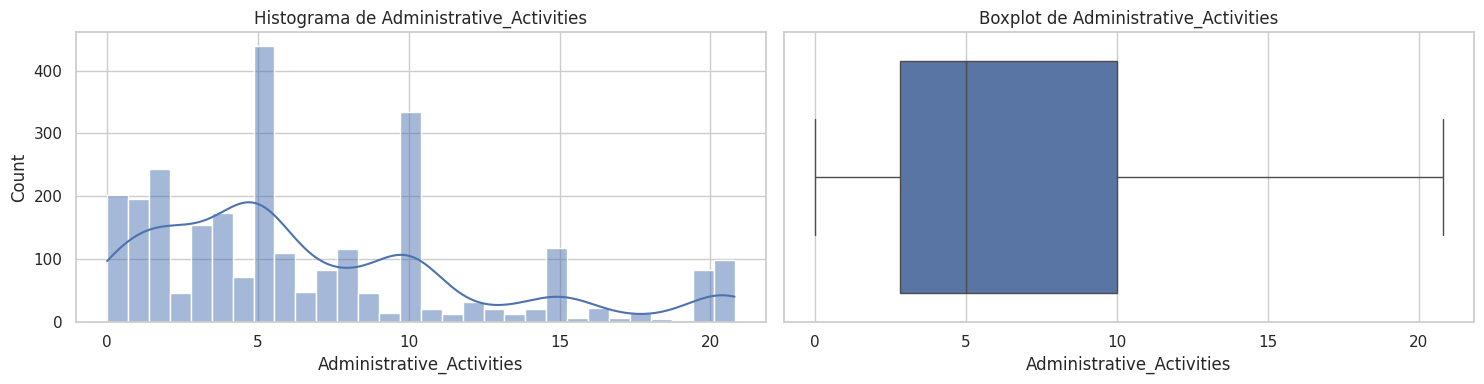

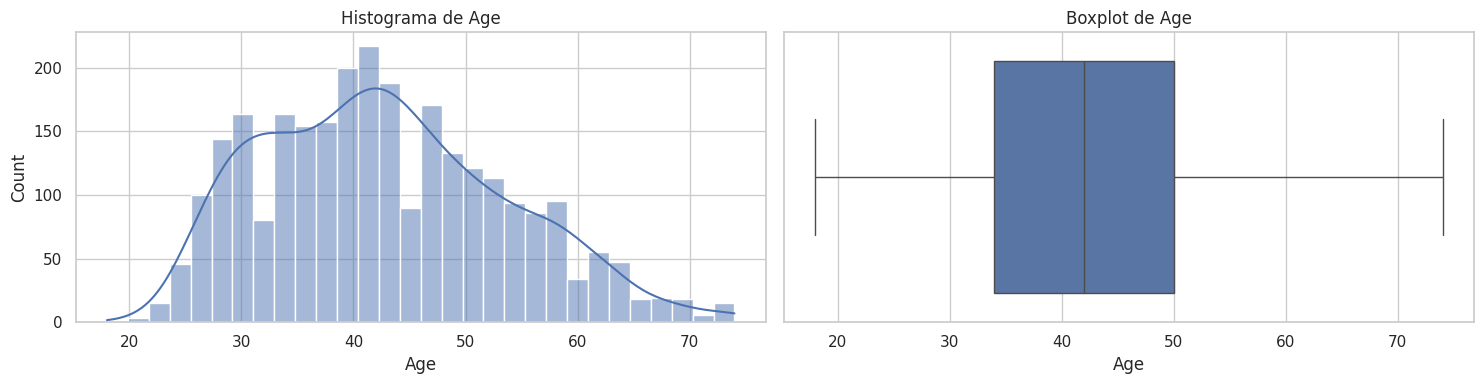

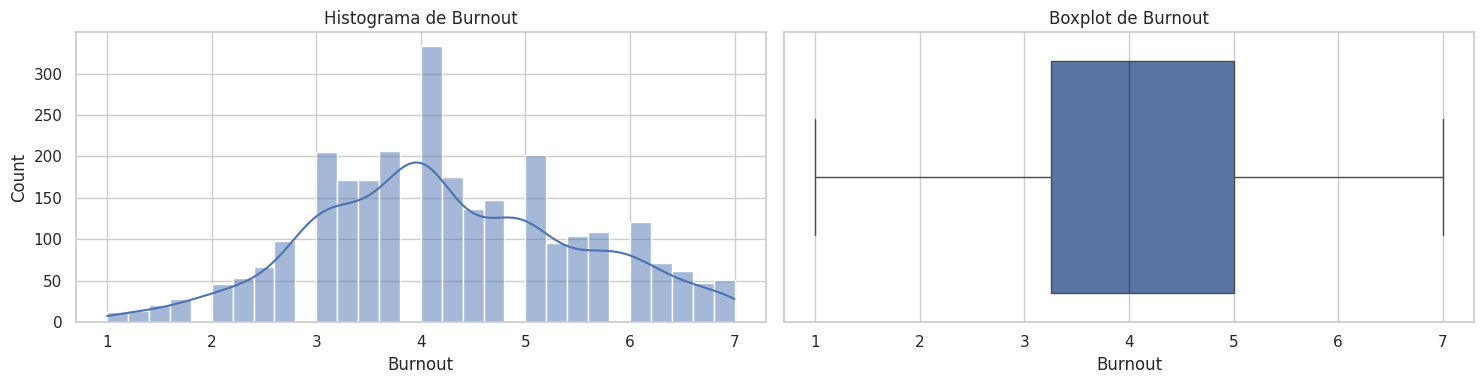

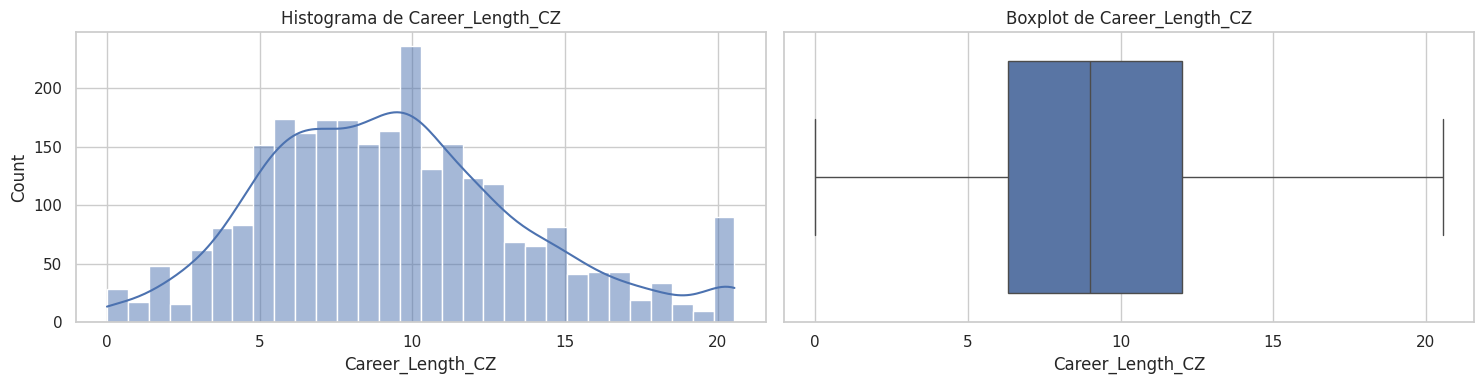

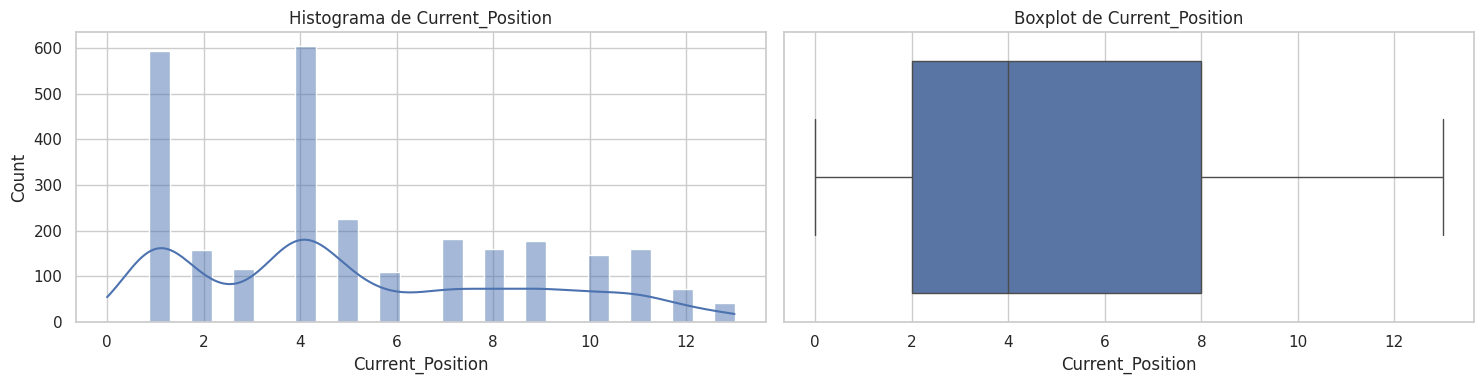

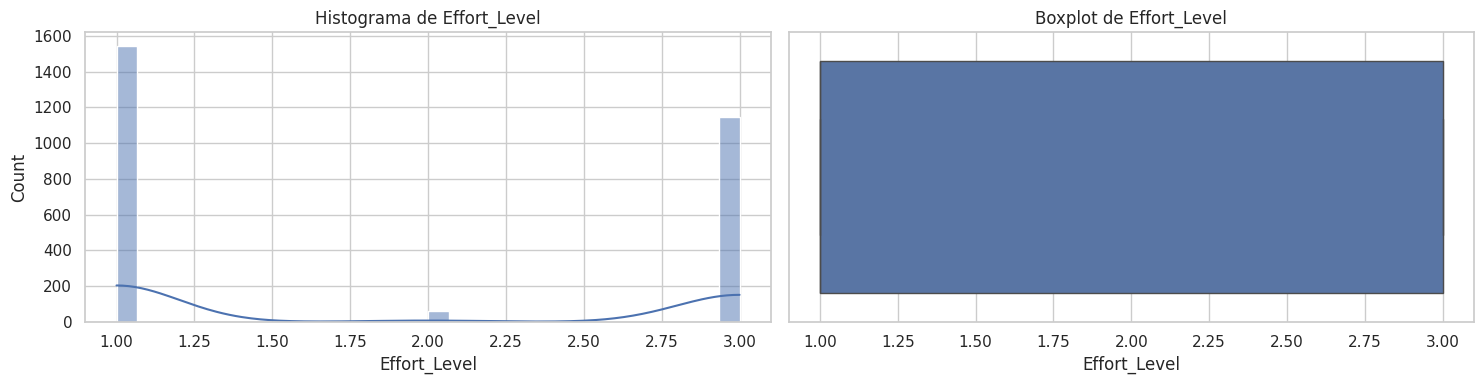

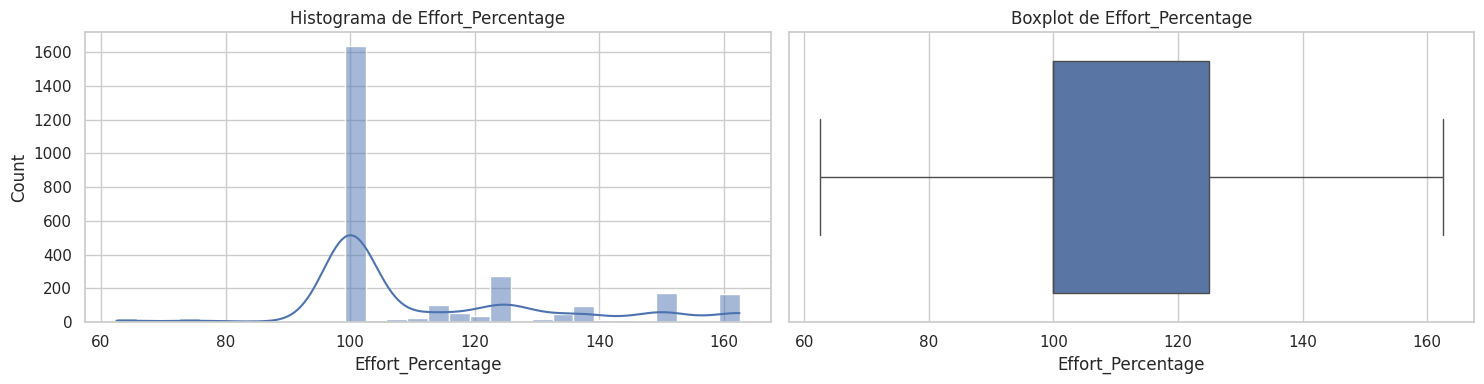

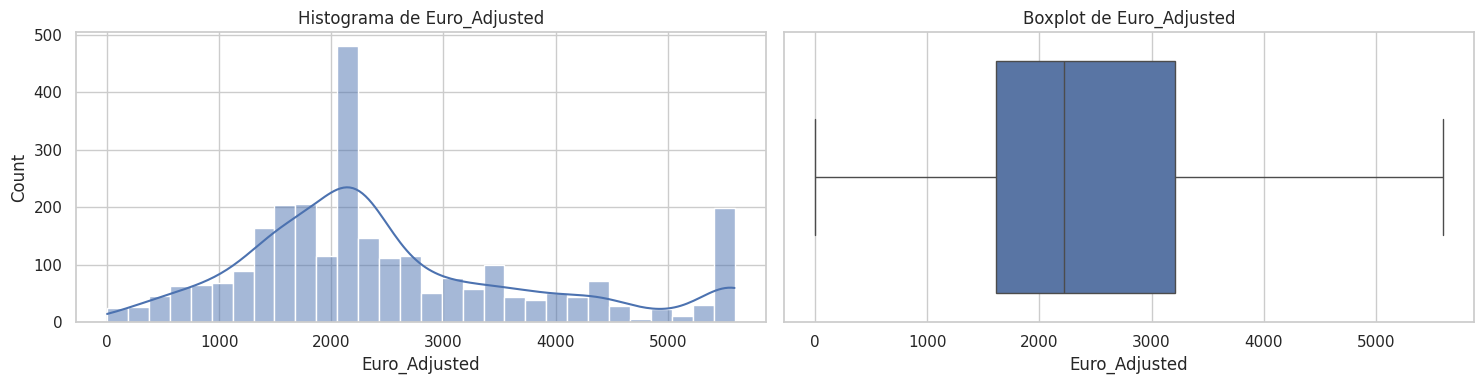

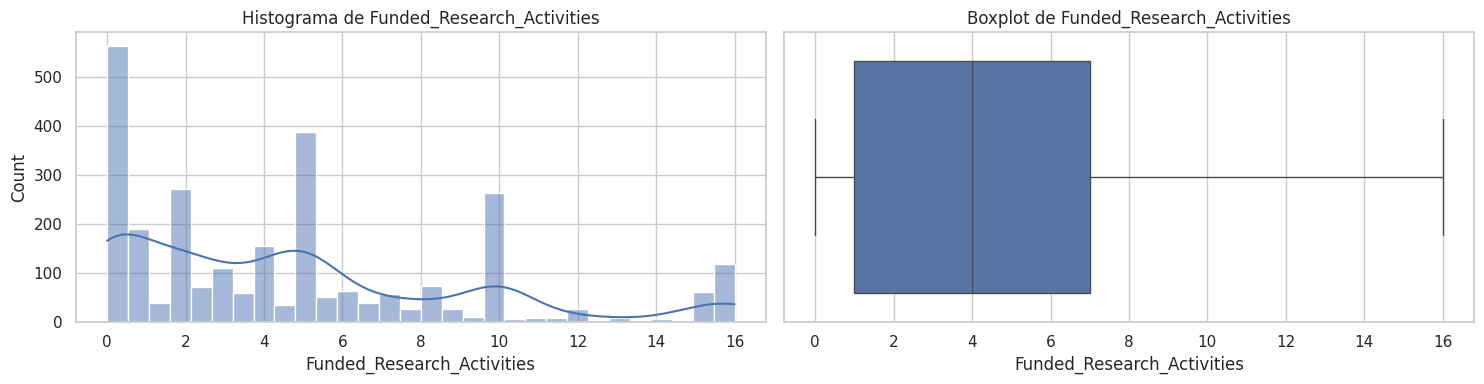

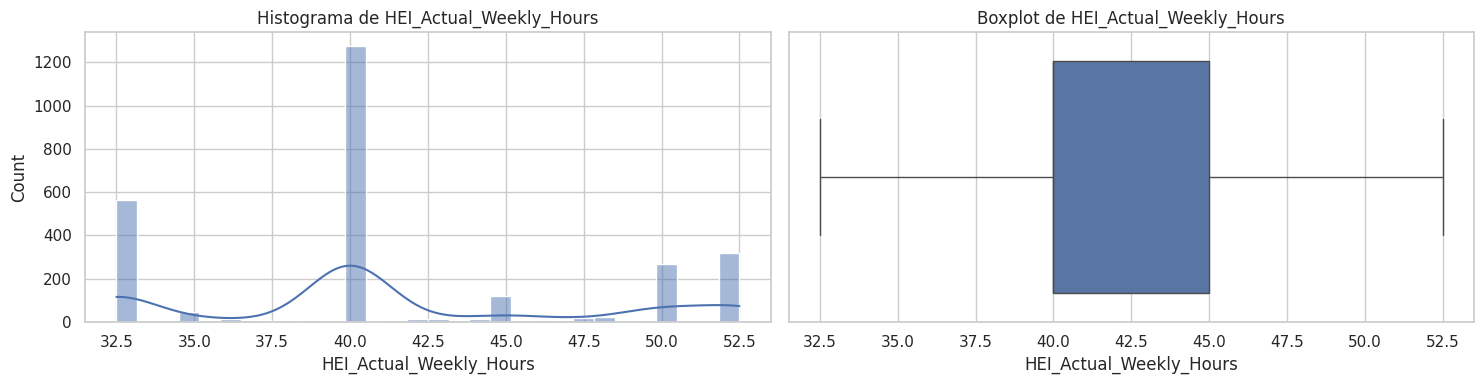

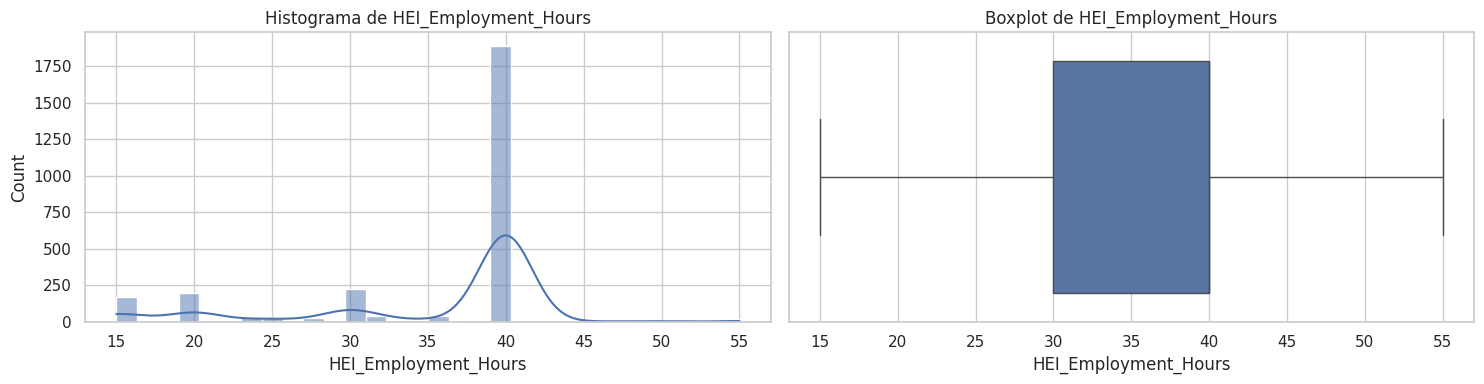

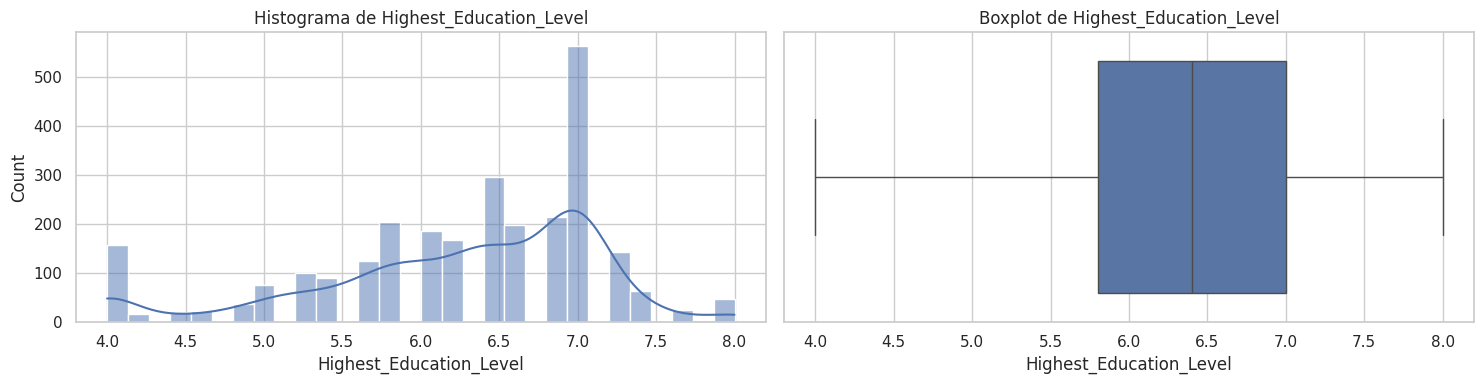

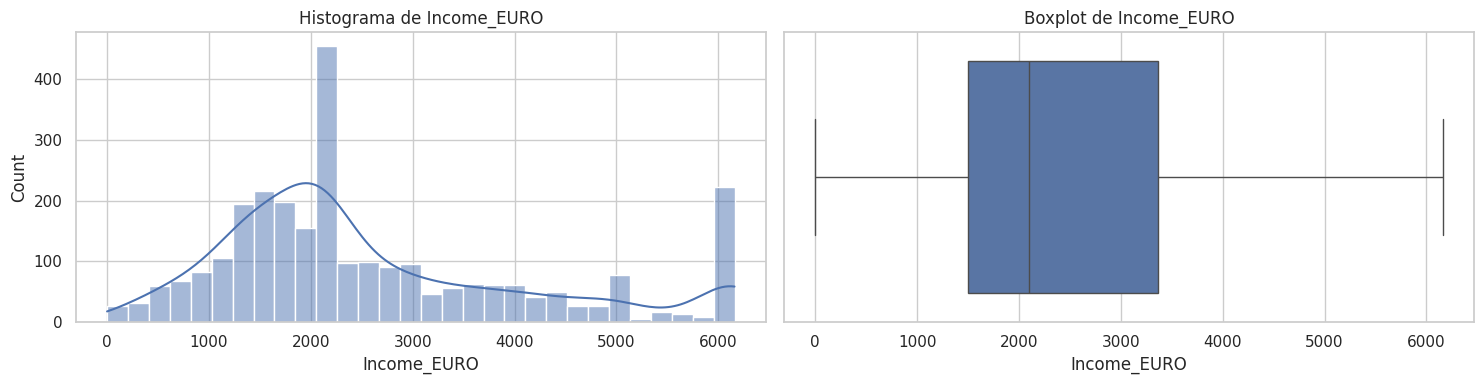

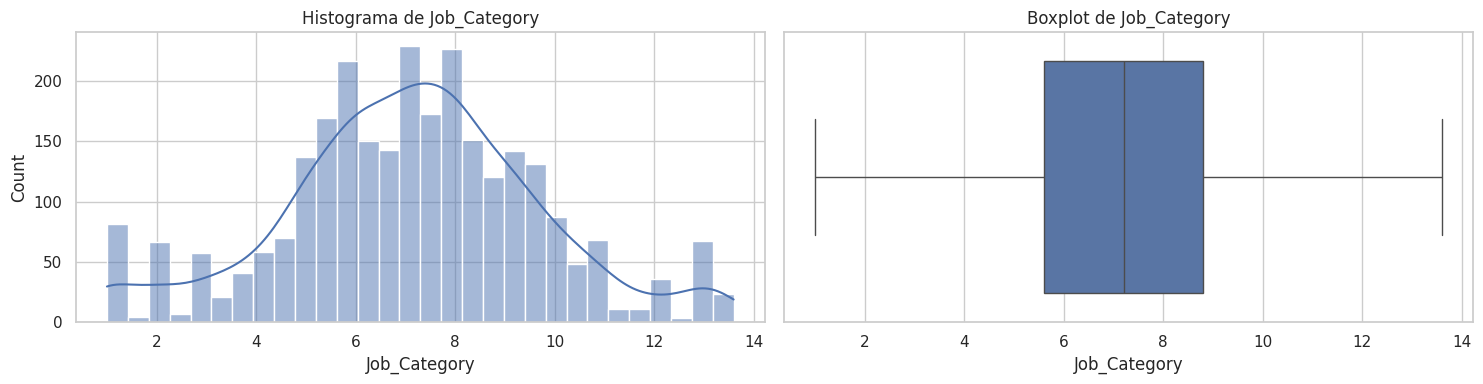

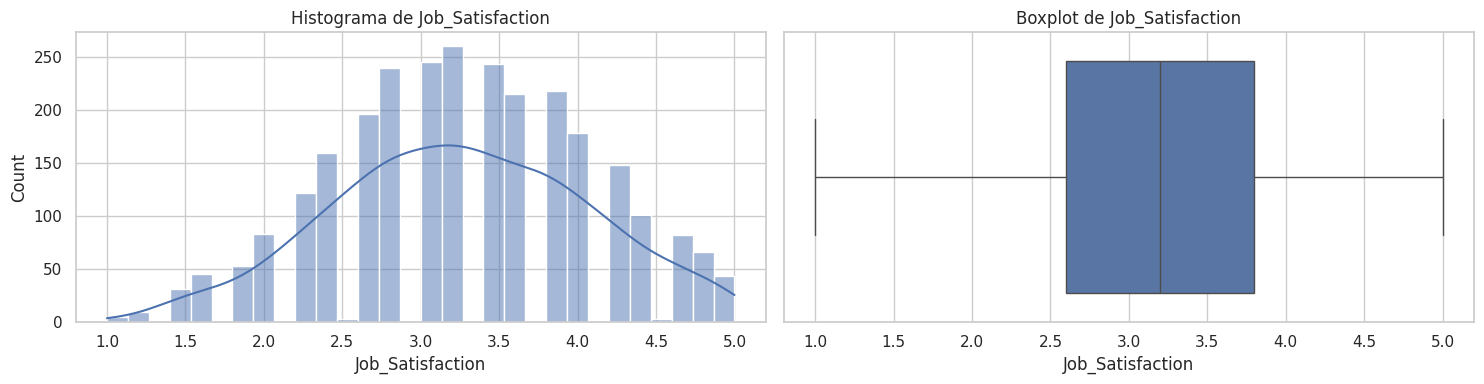

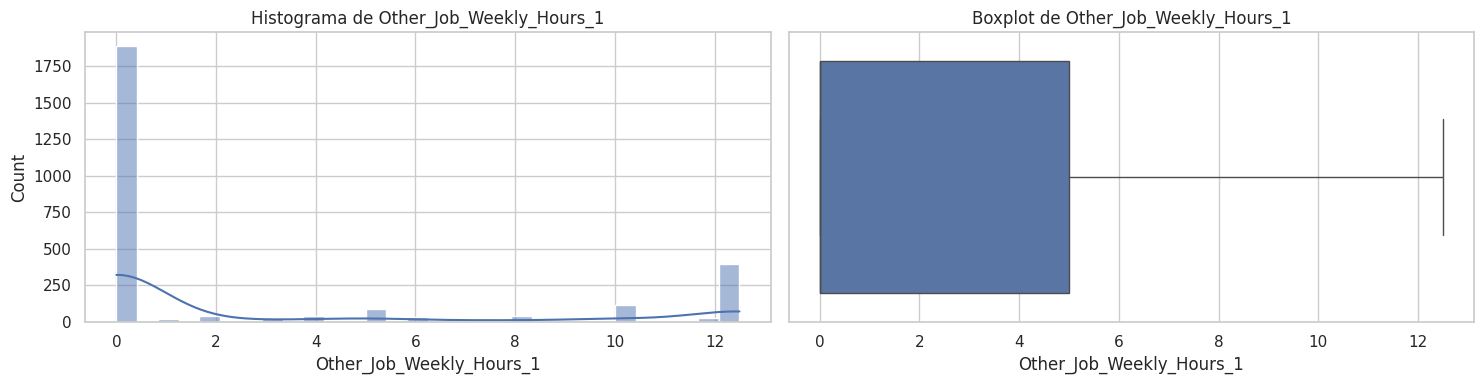

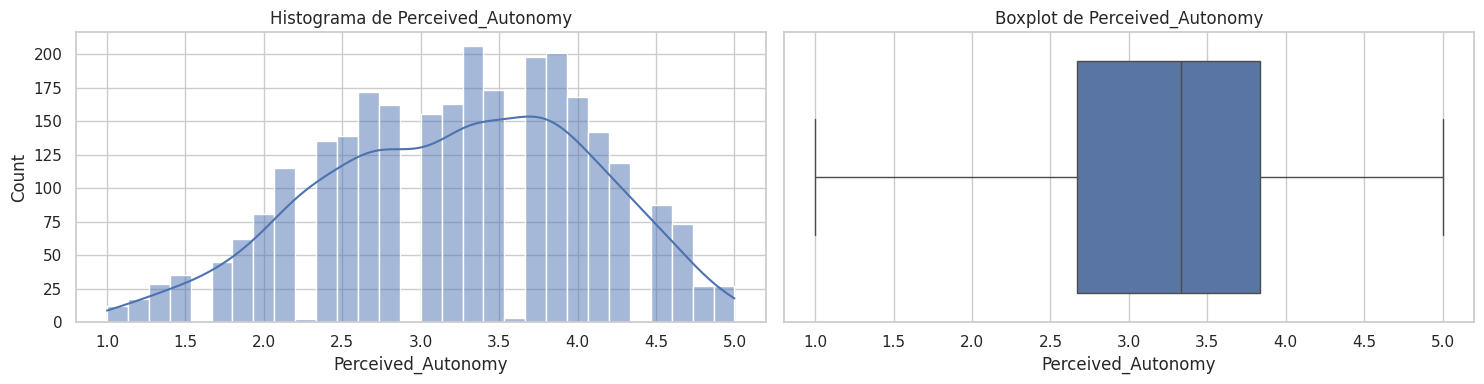

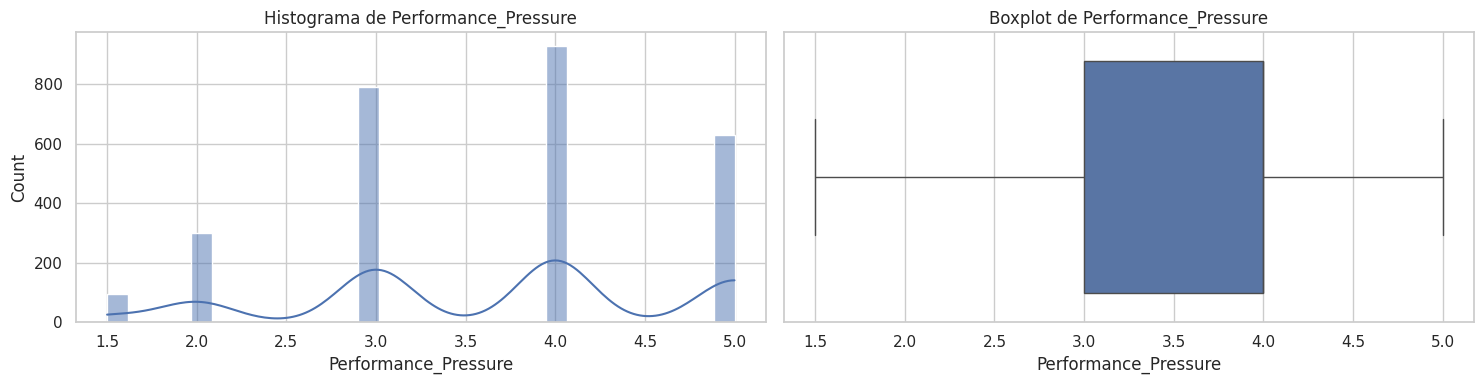

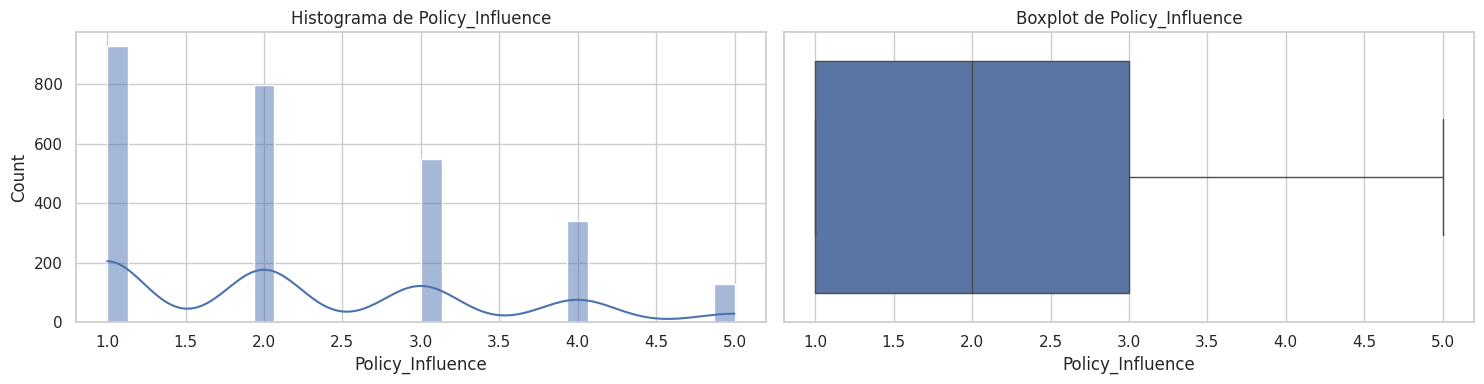

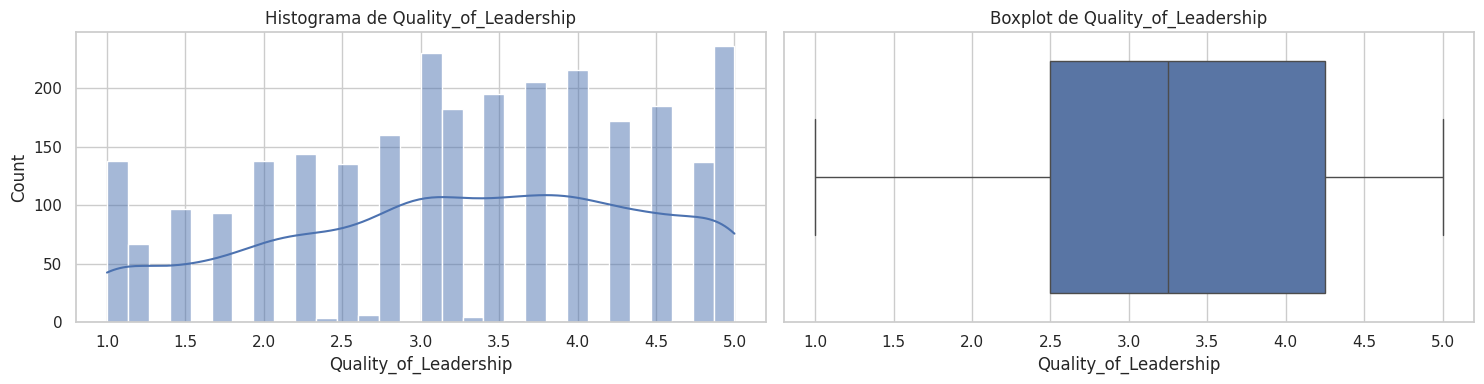

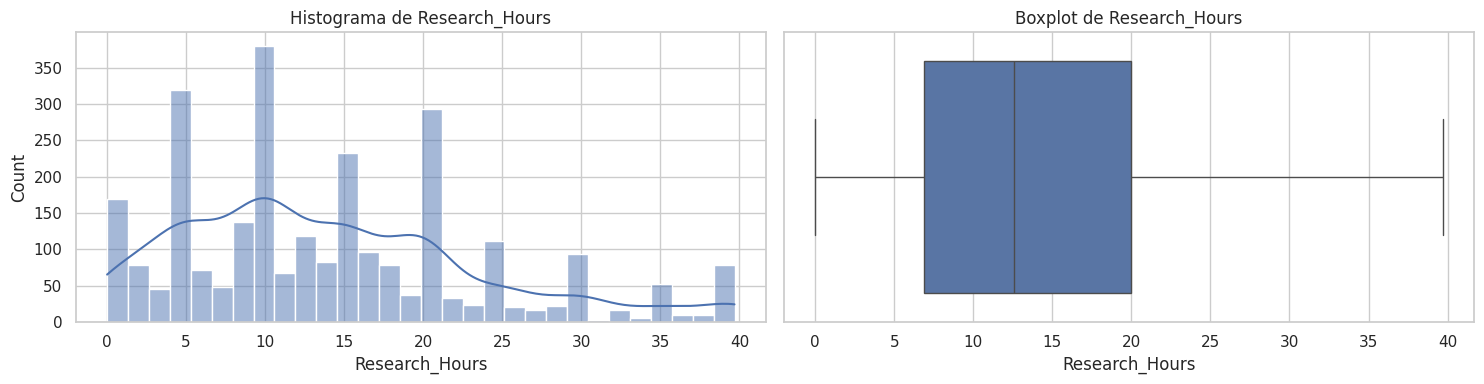

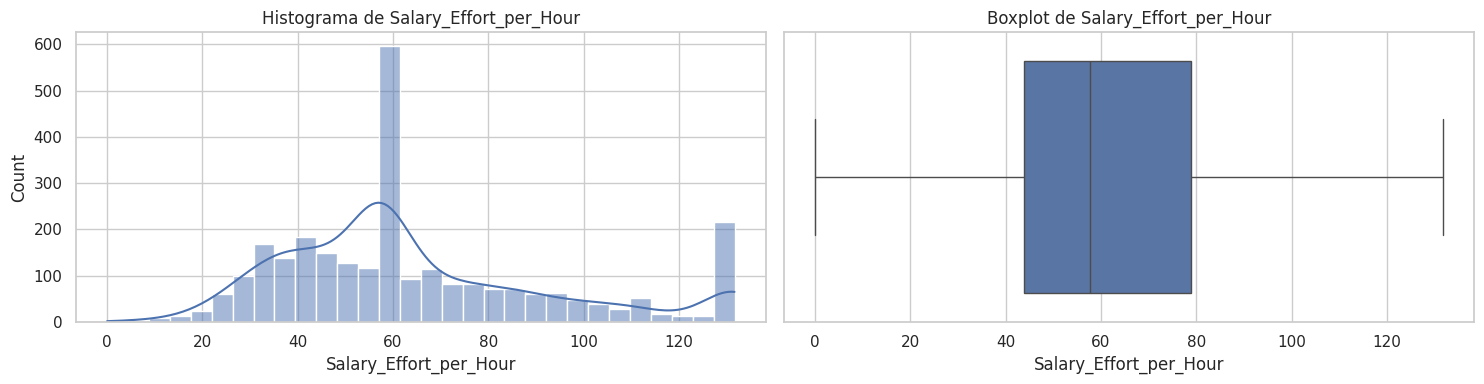

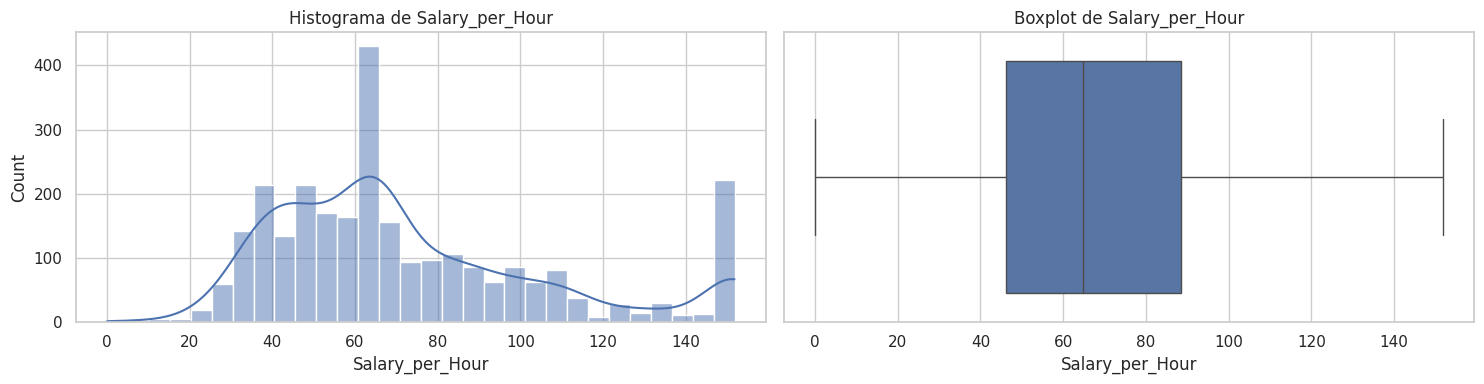

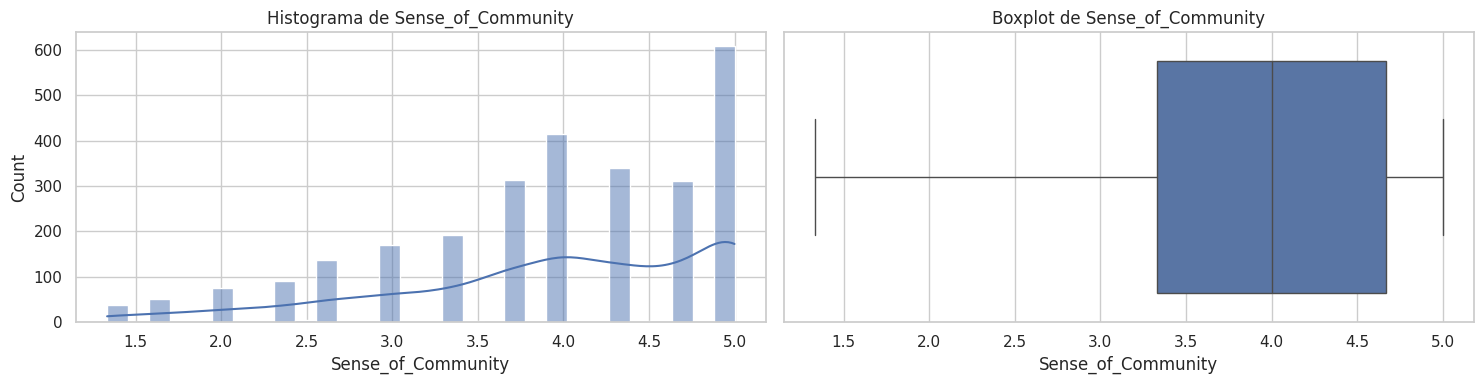

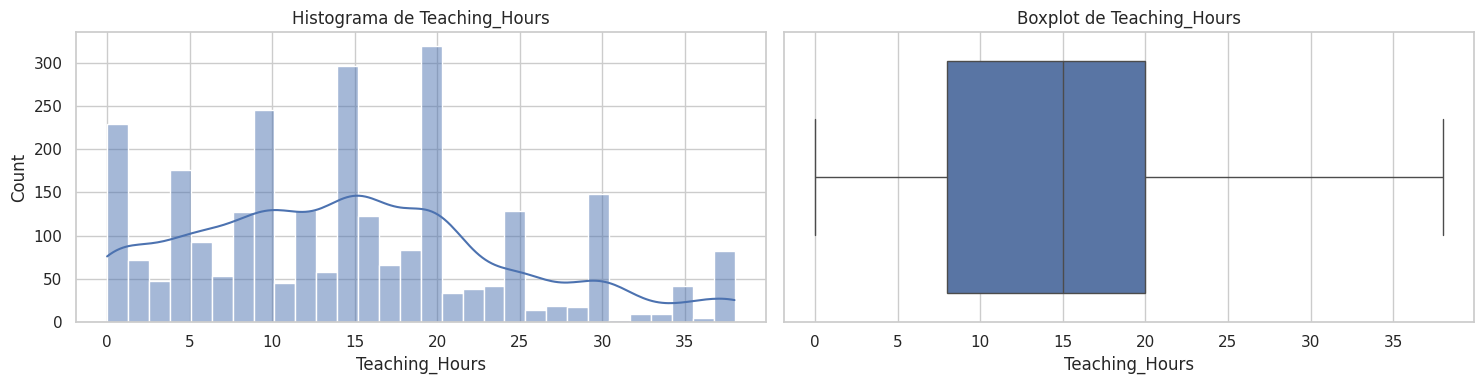

##### Distribuciones Categóricas

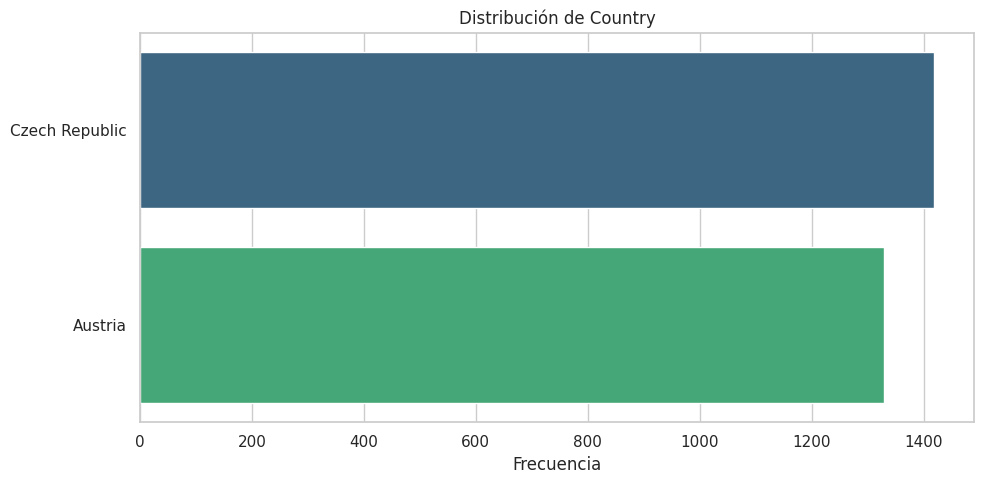

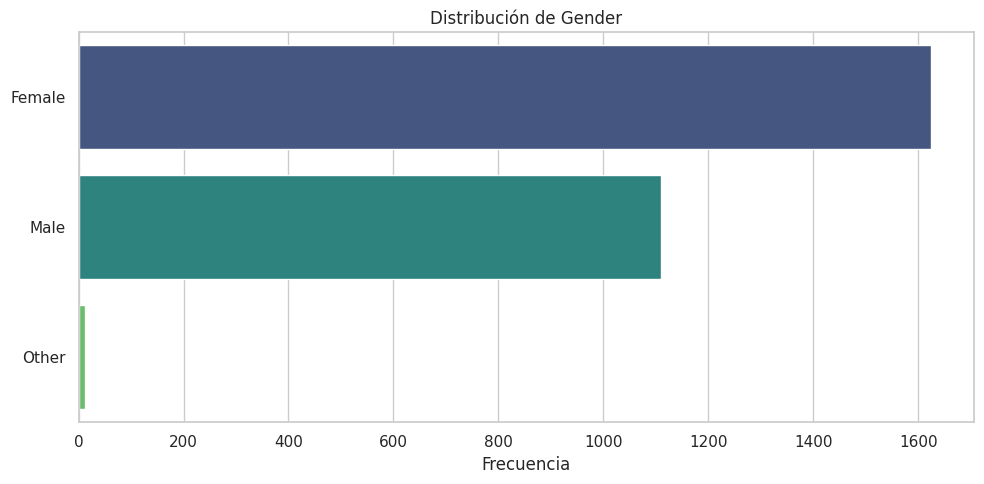

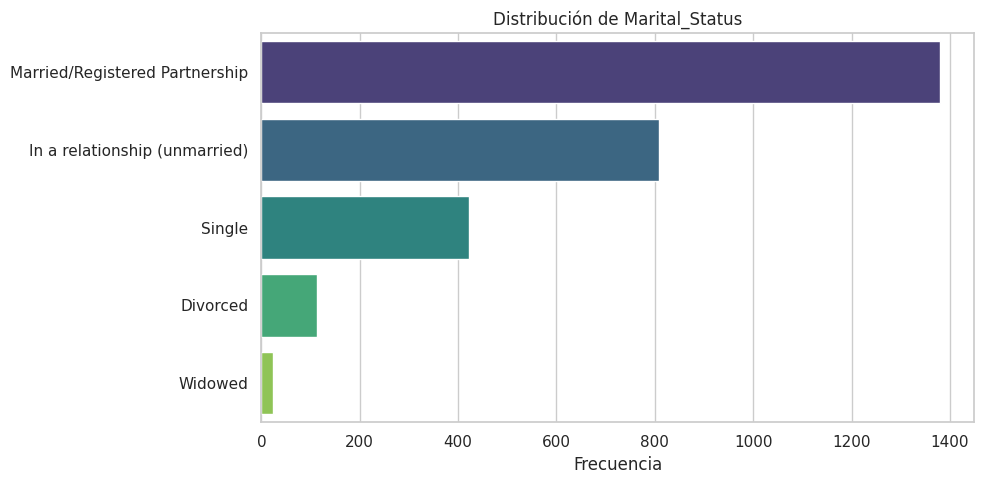

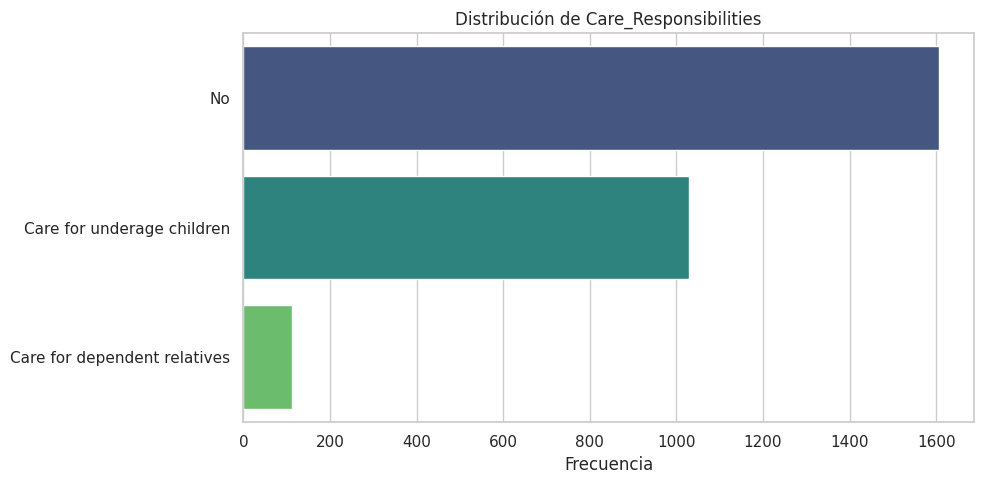

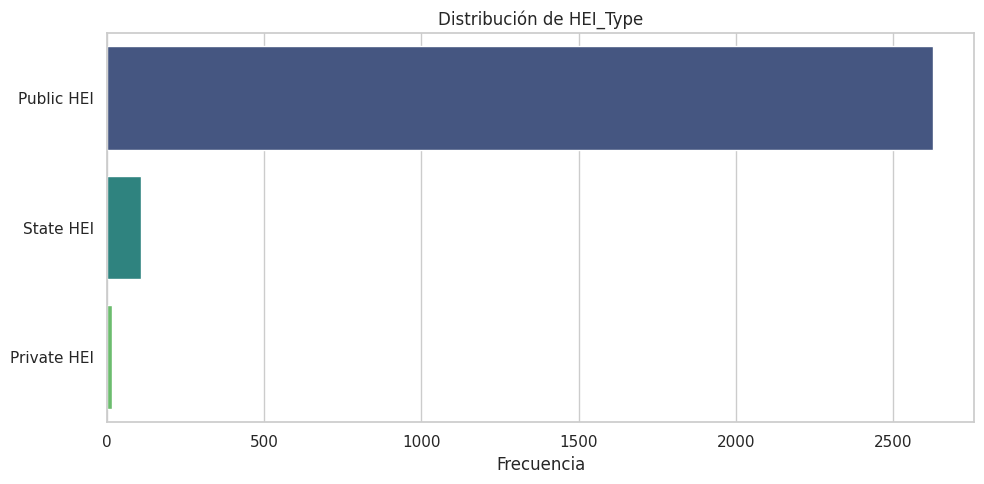

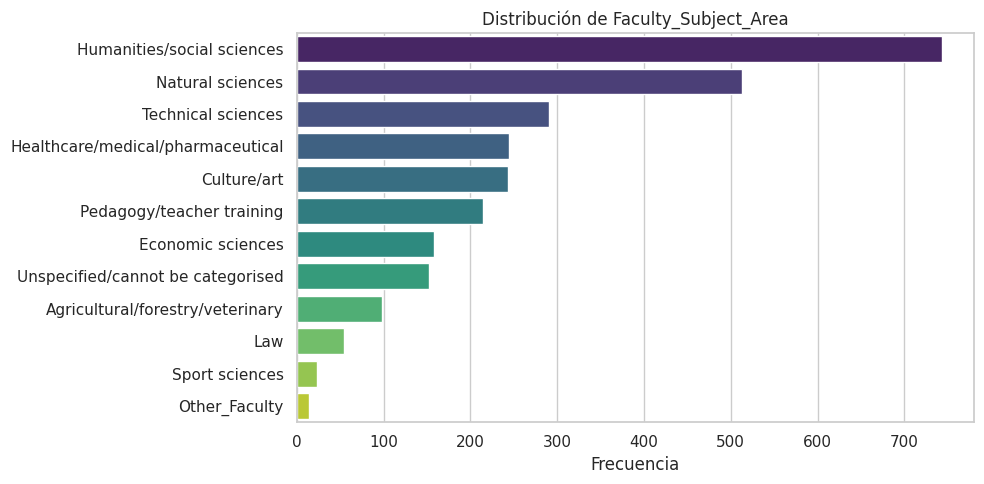

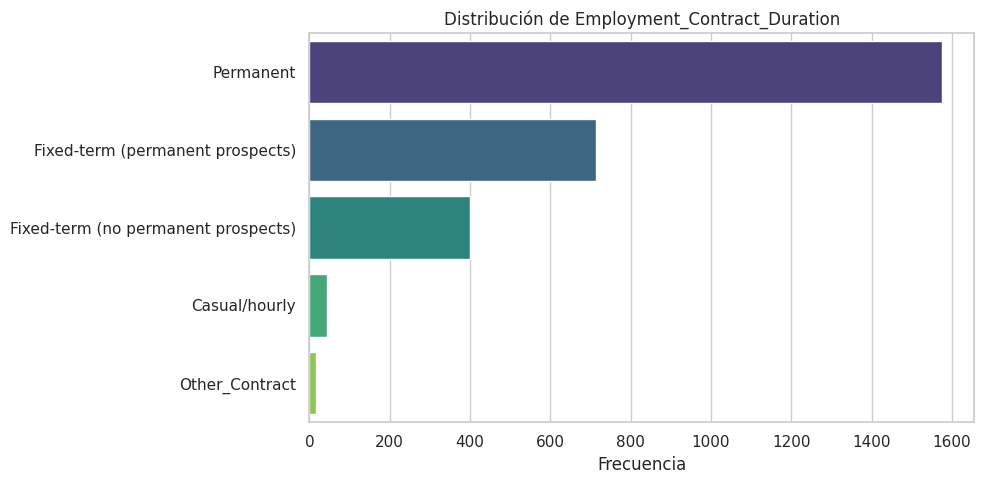

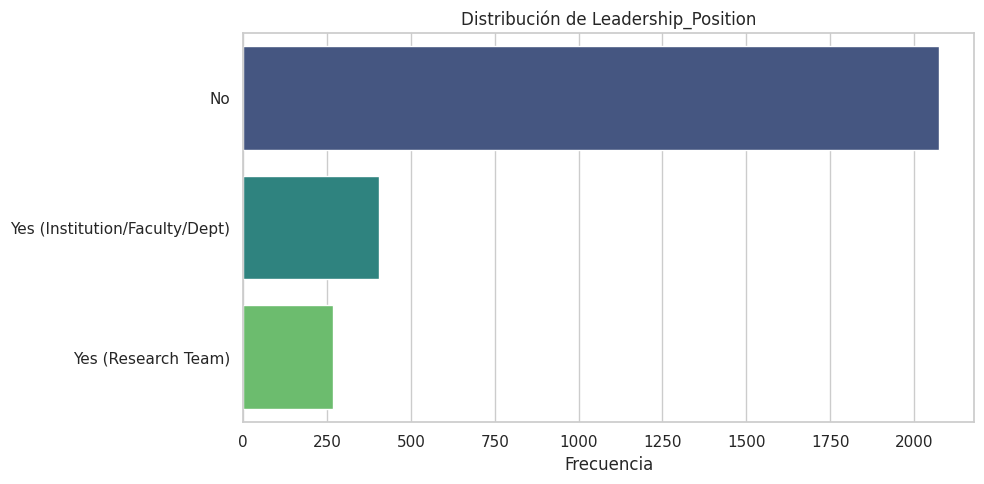

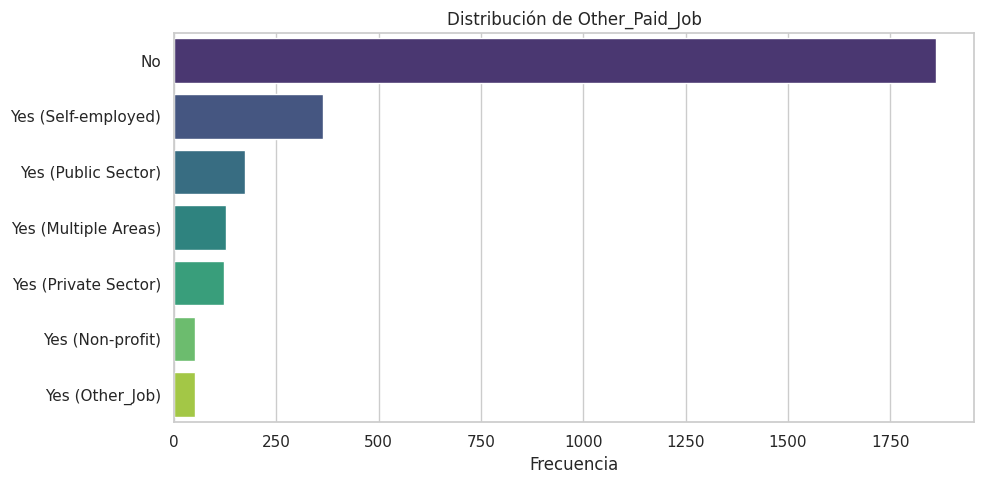

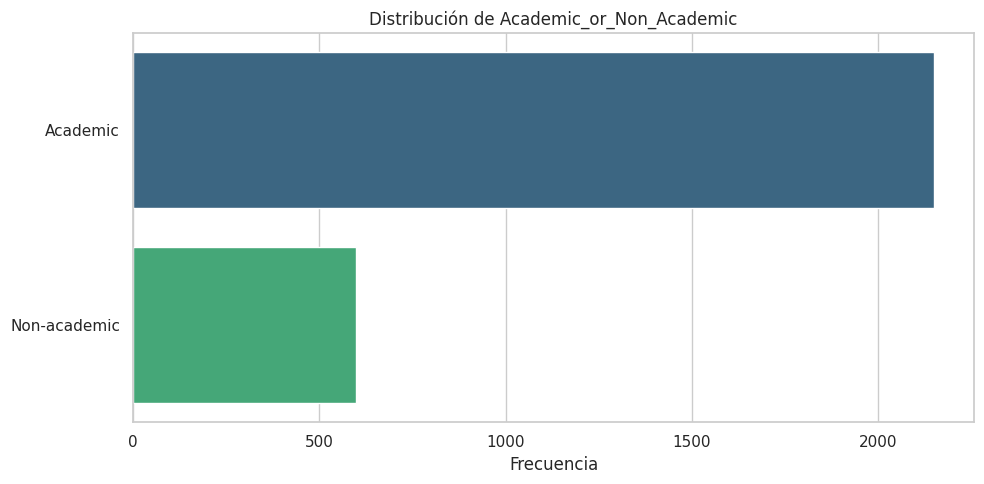

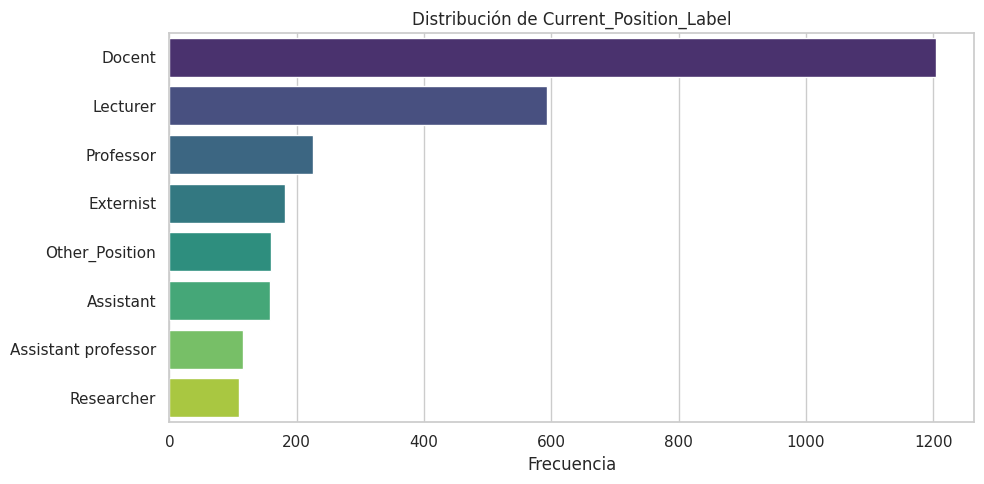

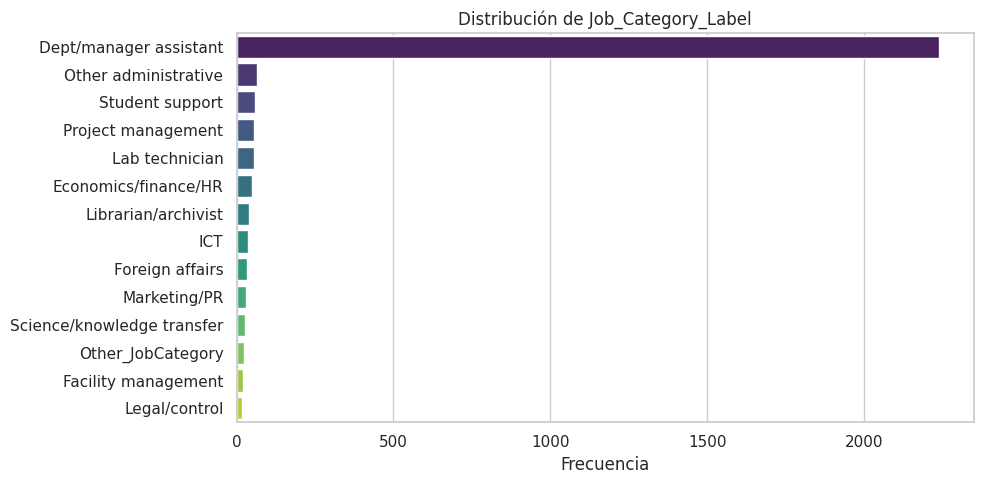

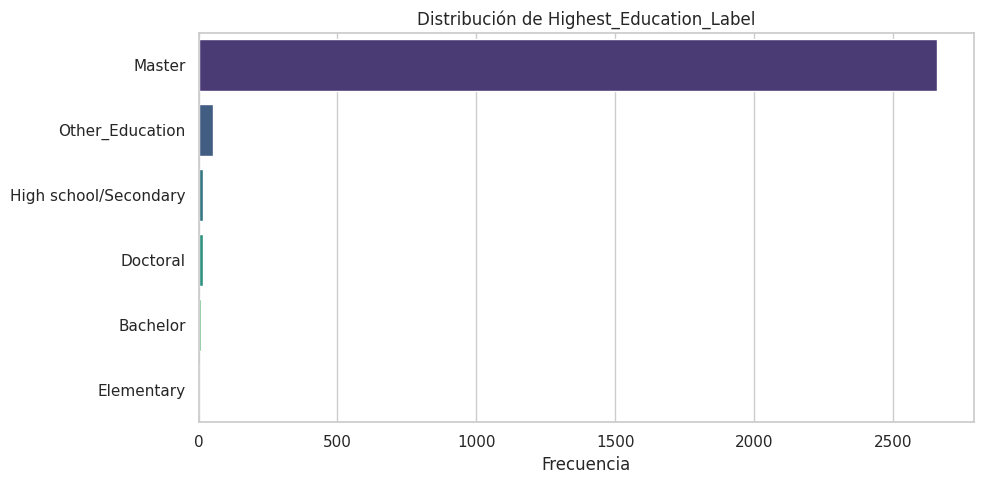

In [17]:
if not df_cleaned.empty:
    display(Markdown("#### Visualizaciones Univariadas"))

    # --- Gráficos para Variables Numéricas (Histograma y Boxplot) ---
    numeric_cols_final = df_cleaned.select_dtypes(include=np.number).columns.difference(['Version']) # Excluir IDs
    display(Markdown("##### Distribuciones Numéricas"))
    for col in numeric_cols_final:
        fig, axes = plt.subplots(1, 2, figsize=(15, 4))

        # Histograma con KDE
        sns.histplot(df_cleaned[col], kde=True, ax=axes[0], bins=30)
        axes[0].set_title(f'Histograma de {col}')

        # Boxplot
        sns.boxplot(x=df_cleaned[col], ax=axes[1])
        axes[1].set_title(f'Boxplot de {col}')

        plt.tight_layout()
        plt.show()

    # --- Gráficos para Variables Categóricas (Gráfico de Barras) ---
    categorical_cols_final = df_cleaned.select_dtypes(include=['category', 'object']).columns
    display(Markdown("##### Distribuciones Categóricas"))
    for col in categorical_cols_final:
        plt.figure(figsize=(10, 5))
        # Ordenar barras por frecuencia descendente para mejor visualización
        order = df_cleaned[col].value_counts().index
        sns.countplot(y=df_cleaned[col], order=order, palette='viridis') # Usar 'y' para etiquetas largas
        plt.title(f'Distribución de {col}')
        plt.xlabel('Frecuencia')
        plt.ylabel('') # Ocultar etiqueta y si es redundante con el título
        plt.tight_layout()
        plt.show()
else:
    print("DataFrame vacío, visualizaciones univariadas omitidas.")

### 5.2 Análisis Multivariado (Correlaciones)

#### Matriz de Correlación (Variables Numéricas)

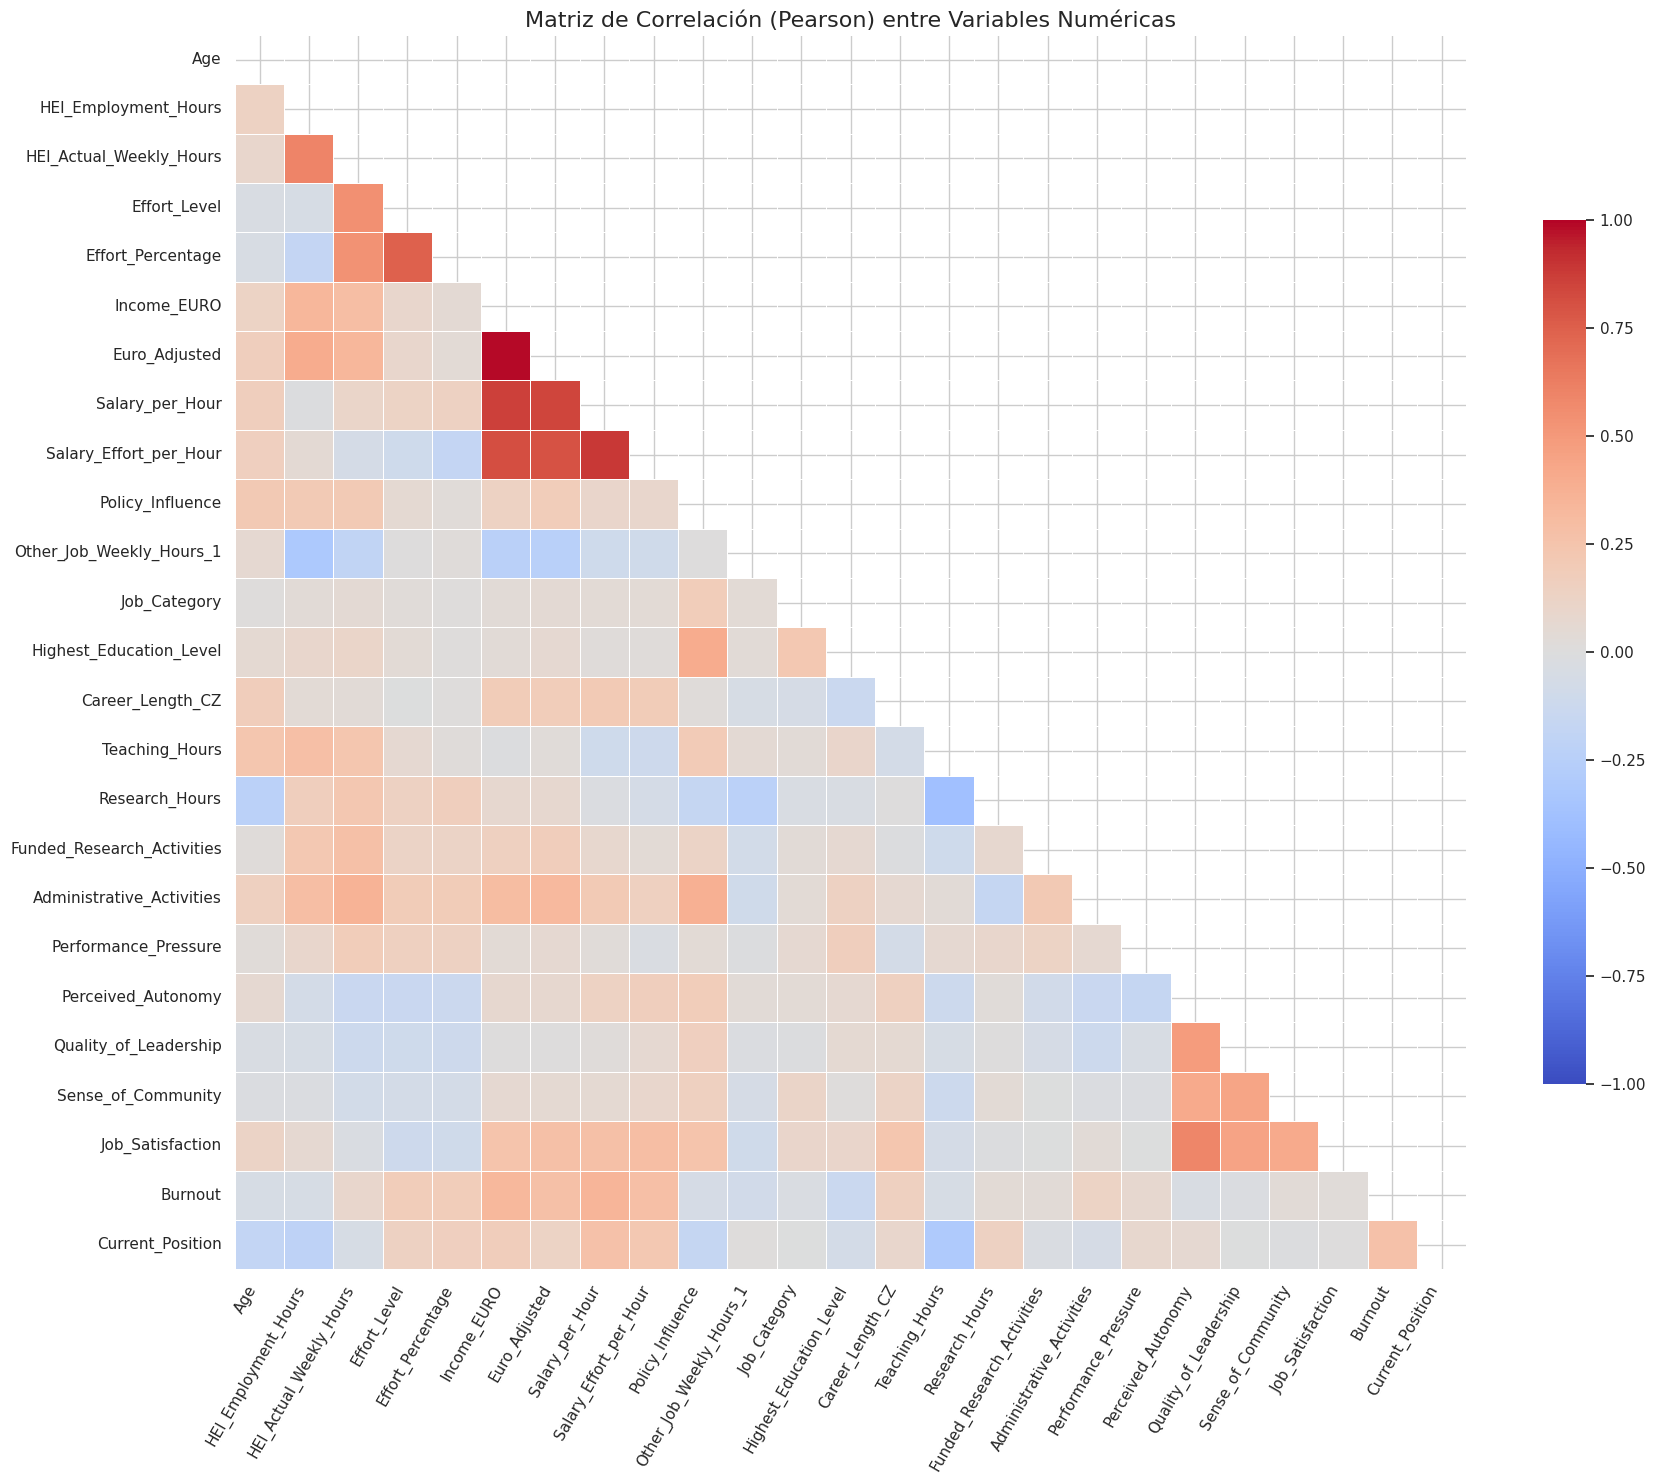

In [18]:
if not df_cleaned.empty:
    display(Markdown("#### Matriz de Correlación (Variables Numéricas)"))

    # Seleccionar solo columnas numéricas para la correlación
    numeric_df = df_cleaned.select_dtypes(include=np.number).drop(columns=['Version'], errors='ignore')

    # Calcular matriz de correlación (Pearson por defecto)
    correlation_matrix = numeric_df.corr(method='pearson')

    # Crear máscara para el triángulo superior
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    # Configurar y mostrar el heatmap
    plt.figure(figsize=(18, 15))
    sns.heatmap(correlation_matrix,
                mask=mask,
                cmap='coolwarm',
                vmax=1, vmin=-1,
                center=0,
                linewidths=.5,
                cbar_kws={"shrink": .7},
                annot=False, # Poner True si quieres ver los valores (puede saturar)
                fmt=".2f") # Formato si annot=True
    plt.title('Matriz de Correlación (Pearson) entre Variables Numéricas', fontsize=16)
    plt.xticks(rotation=60, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame vacío, análisis de correlación omitido.")

### 5.3 Análisis de Disparidades (Estadísticas Agrupadas y Gráficos Comparativos)

Exploraremos cómo las variables clave de bienestar varían según:
* `Country`
* `Gender`
* `HEI_Type`
* `Faculty_Subject_Area`
* Grupo de Edad (`Age_Group` - a crear)

In [19]:
if not df_cleaned.empty:
    # Crear grupos de edad
    age_bins = [0, 29, 39, 49, 59, np.inf] # Definir límites: <=29, 30-39, 40-49, 50-59, 60+
    age_labels = ['<30', '30-39', '40-49', '50-59', '60+']
    if 'Age' in df_cleaned.columns:
        df_cleaned['Age_Group'] = pd.cut(df_cleaned['Age'], bins=age_bins, labels=age_labels, right=True)
        print("Columna 'Age_Group' creada.")
        display(df_cleaned[['Age', 'Age_Group']].head())
    else:
        print("Columna 'Age' no encontrada, no se pudo crear 'Age_Group'.")
else:
    print("DataFrame vacío, creación de grupo de edad omitida.")

Columna 'Age_Group' creada.


,Age,Age_Group
0,28.0,<30
1,33.0,30-39
2,32.0,30-39
3,30.0,30-39
4,39.0,30-39


Variables de bienestar a analizar: ['Job_Satisfaction', 'Burnout', 'Perceived_Autonomy', 'Performance_Pressure', 'Quality_of_Leadership', 'Sense_of_Community', 'Salary_per_Hour', 'HEI_Actual_Weekly_Hours']


#### Análisis Agrupado por: Country

Job_Satisfaction          Burnout        Perceived_Autonomy  \
                           mean median      mean median               mean   
Country                                                                      
Austria                3.353988    3.4  5.014322    5.0           3.303612   
Czech Republic         3.151947    3.2  3.518910    3.5           3.155015   

                         Performance_Pressure        Quality_of_Leadership  \
                  median                 mean median                  mean   
Country                                                                      
Austria         3.333333             3.581339    4.0              3.274053   
Czech Republic  3.166667             3.690486    4.0              3.242612   

                      Sense_of_Community           Salary_per_Hour             \
               median               mean    median            mean     median   
Country                                                                         
Austria          3.50           4.030976  4.333333       93.400728  84.510400   
Czech Republic   3.25           3.846065  4.000000       53.539238  48.466922   

               HEI_Actual_Weekly_Hours         
                                  mean median  
Country                                        
Austria                      40.770956   40.0  
Czech Republic               41.603594   40.0

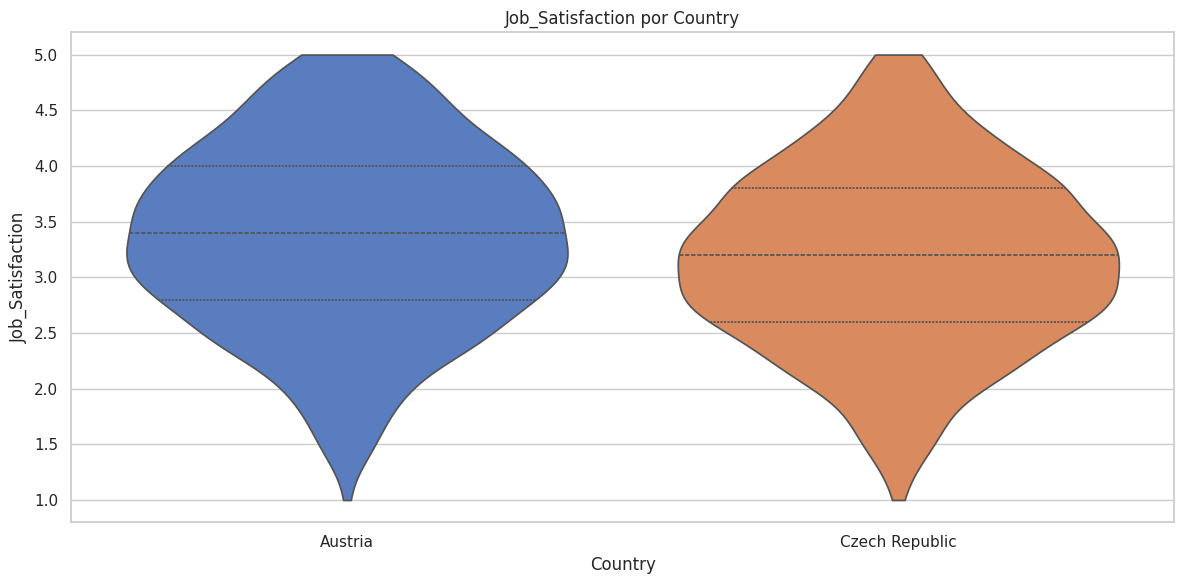

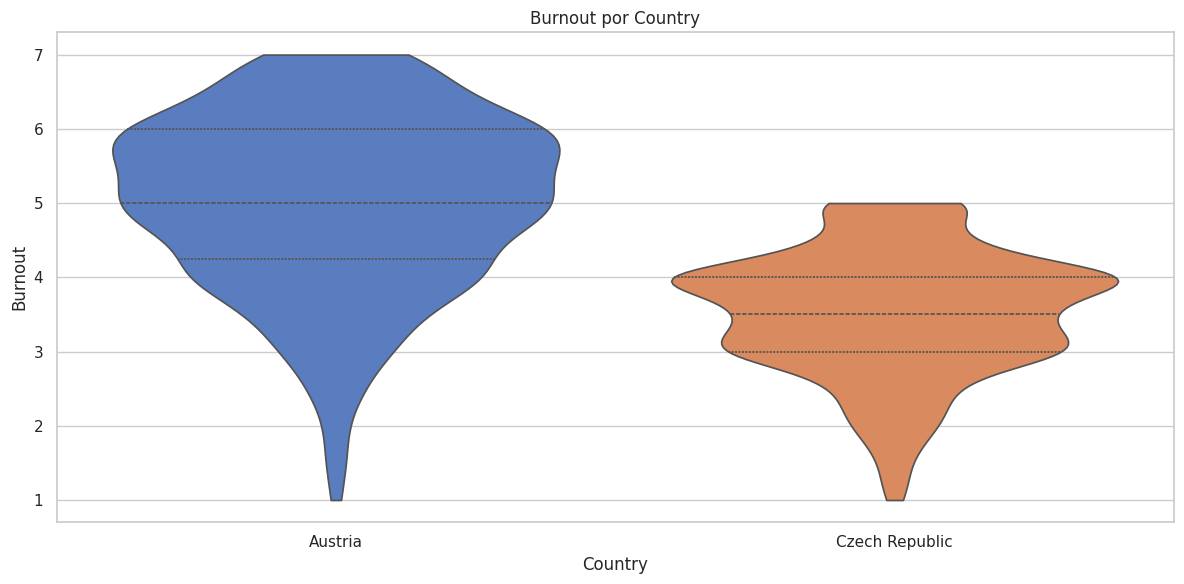

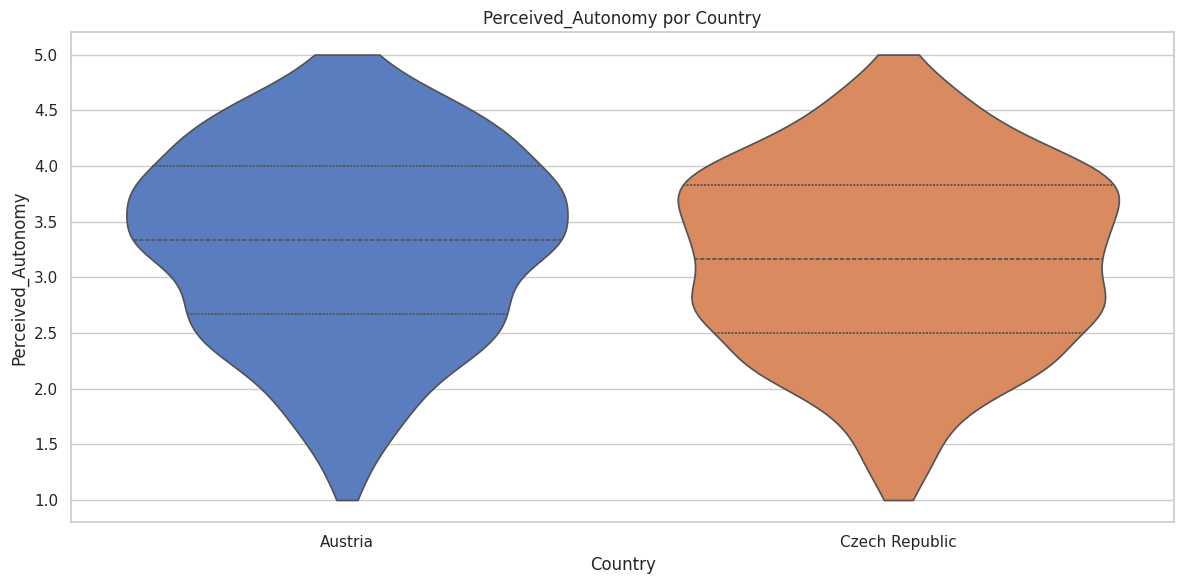

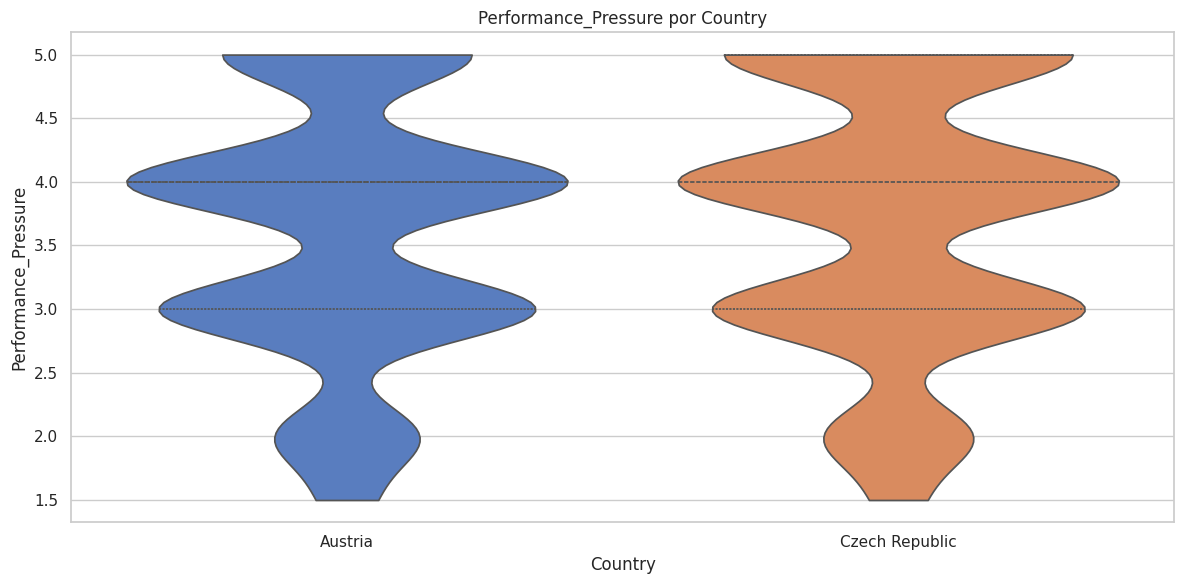

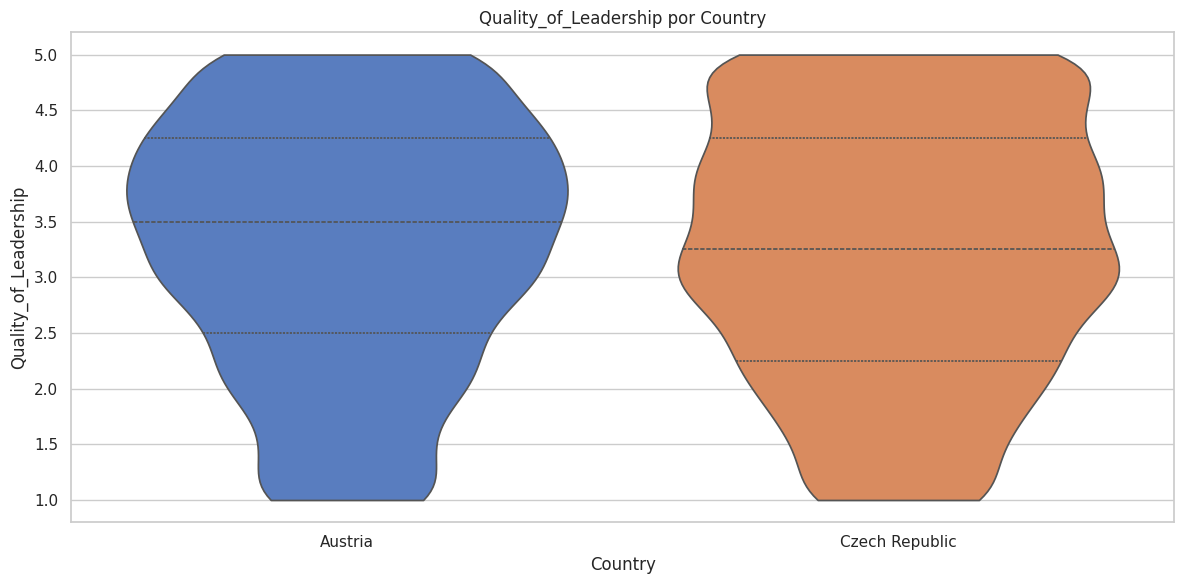

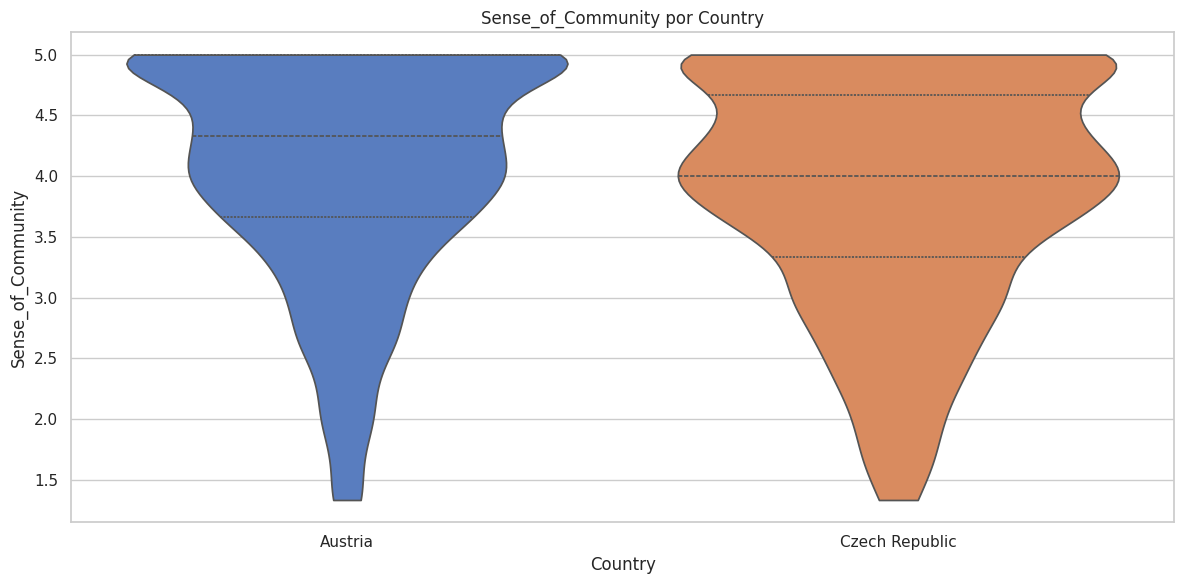

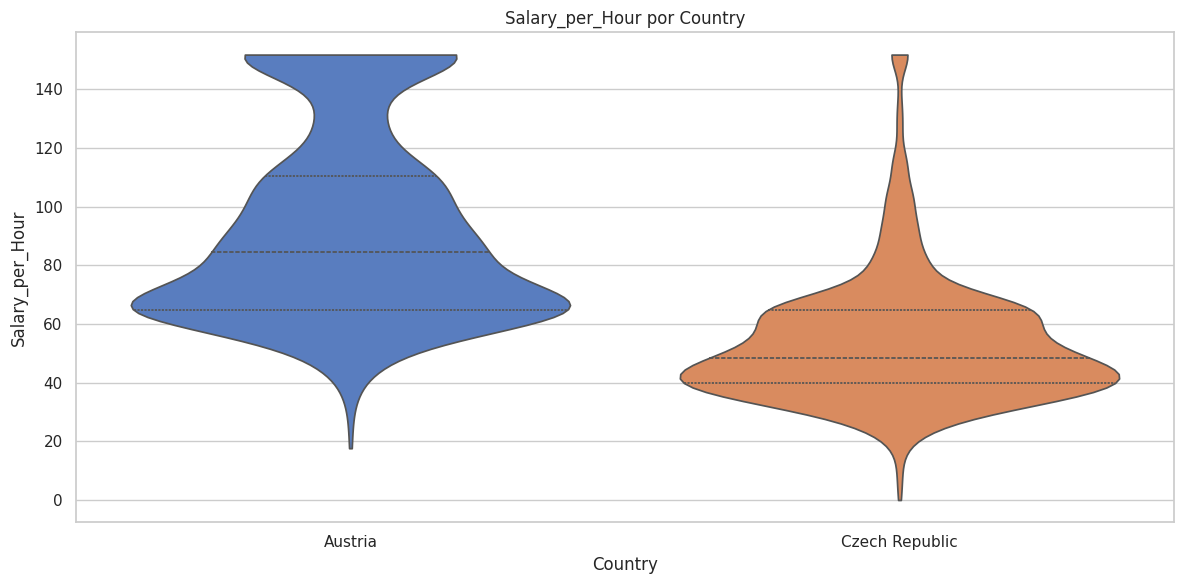

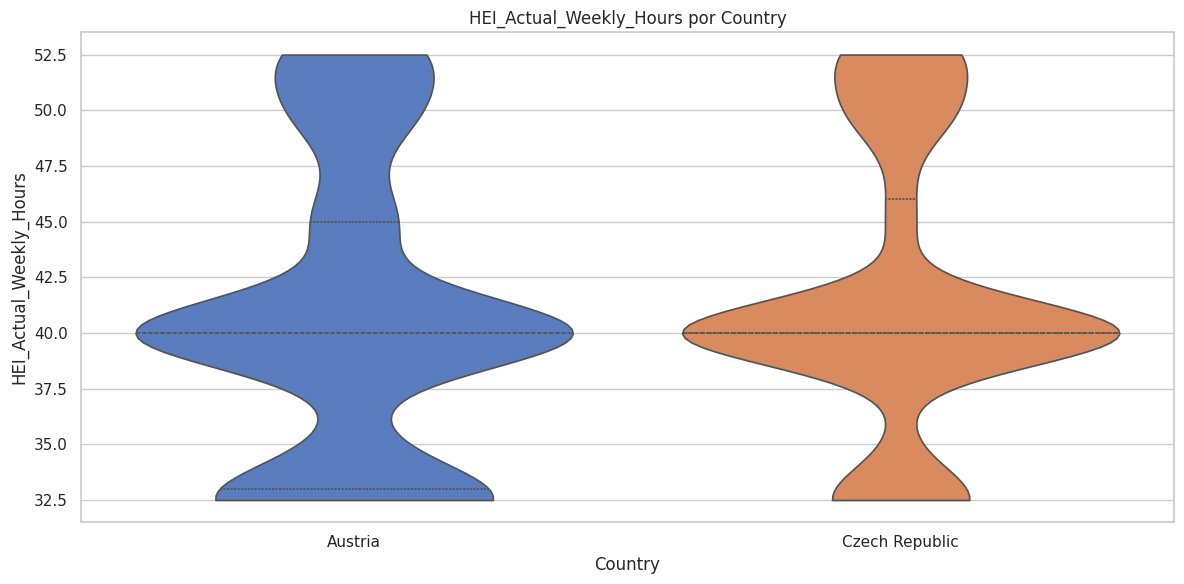

#### Análisis Agrupado por: Gender

Job_Satisfaction          Burnout        Perceived_Autonomy            \
                   mean median      mean median               mean    median   
Gender                                                                         
Female         3.201461    3.2  4.348738   4.25           3.161969  3.166667   
Male           3.322243    3.4  4.077853   4.00           3.327117  3.333333   
Other          3.076923    3.0  4.942308   5.00           2.782051  2.666667   

       Performance_Pressure        Quality_of_Leadership         \
                       mean median                  mean median   
Gender                                                            
Female             3.671446    4.0              3.204985   3.25   
Male               3.584955    4.0              3.334805   3.50   
Other              3.923077    4.0              3.288462   3.50   

       Sense_of_Community           Salary_per_Hour             \
                     mean    median            mean     median   
Gender                                                           
Female           3.954605  4.000000       68.824439  64.826667   
Male             3.906156  4.000000       78.766850  65.776537   
Other            4.051282  4.333333       63.910005  61.495652   

       HEI_Actual_Weekly_Hours         
                          mean median  
Gender                                 
Female               40.639292   40.0  
Male                 42.055631   40.0  
Other                38.423077   32.5

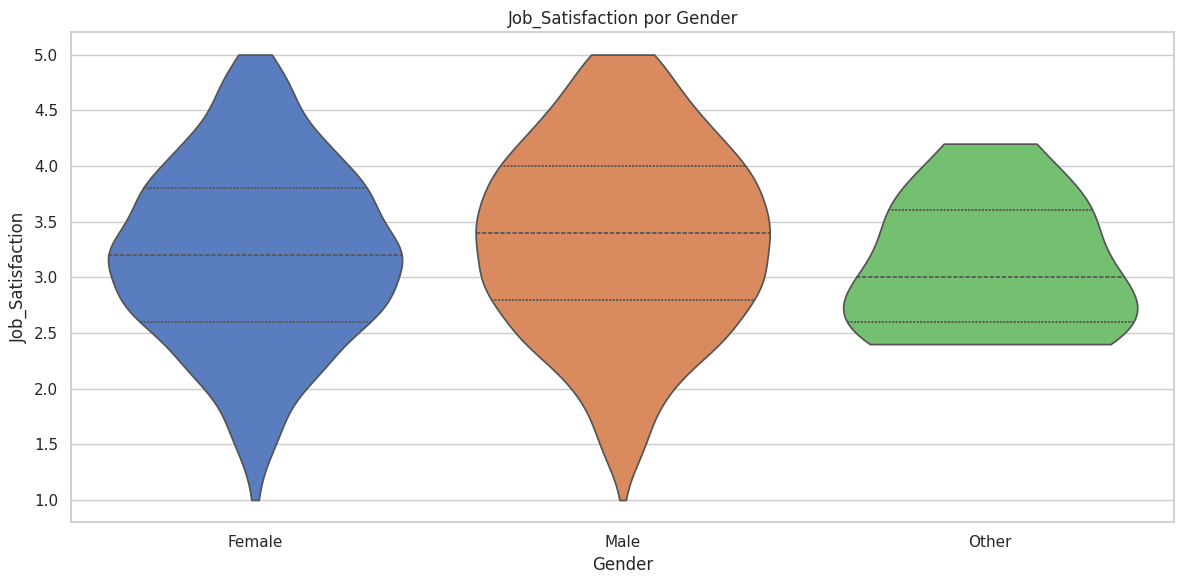

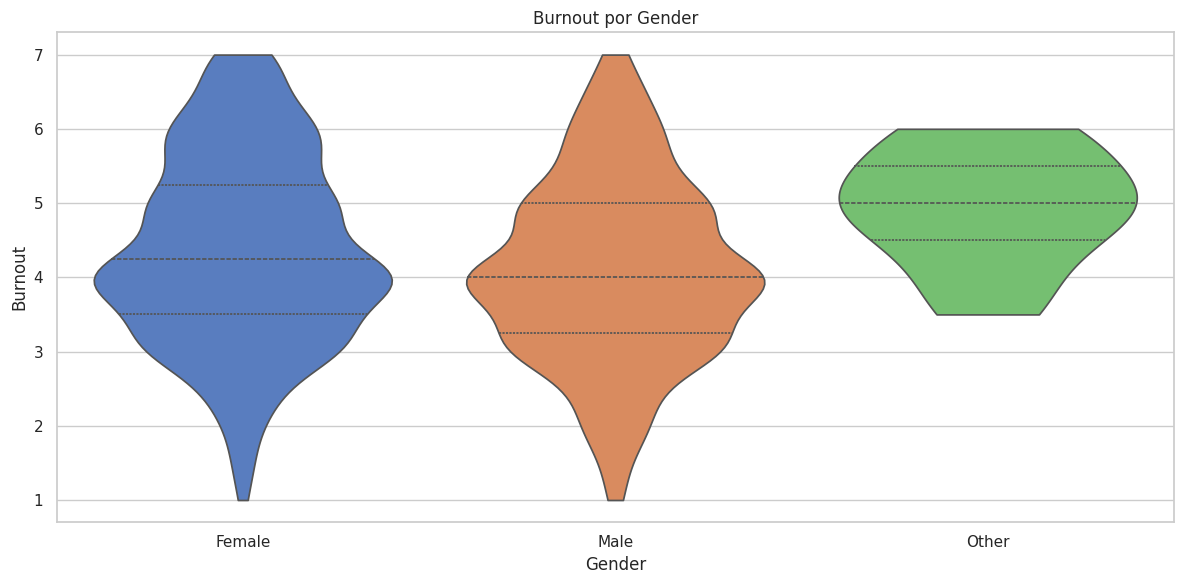

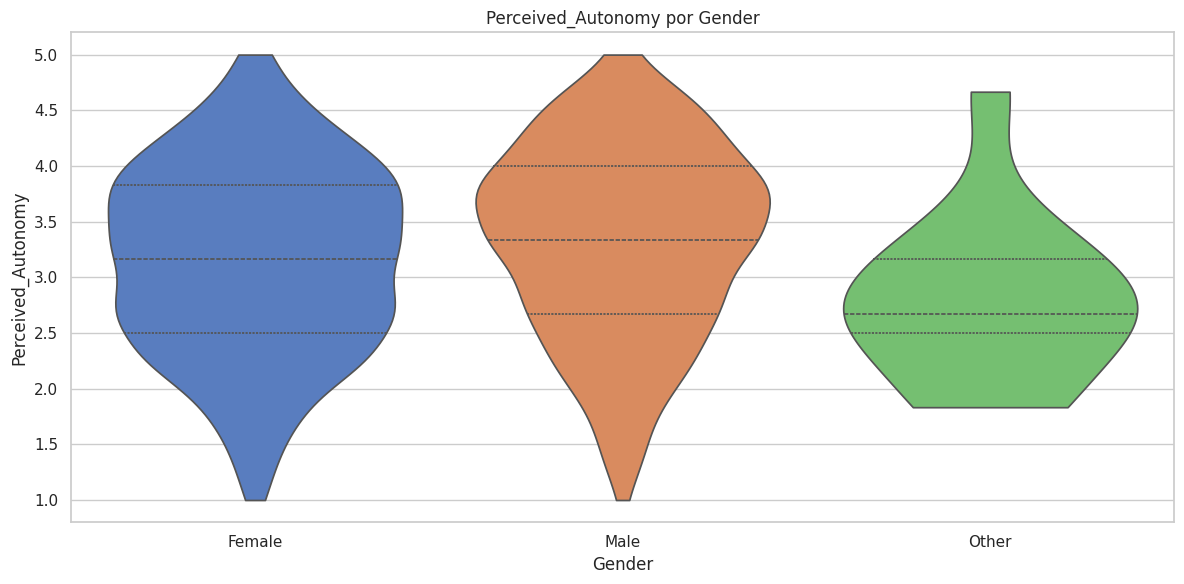

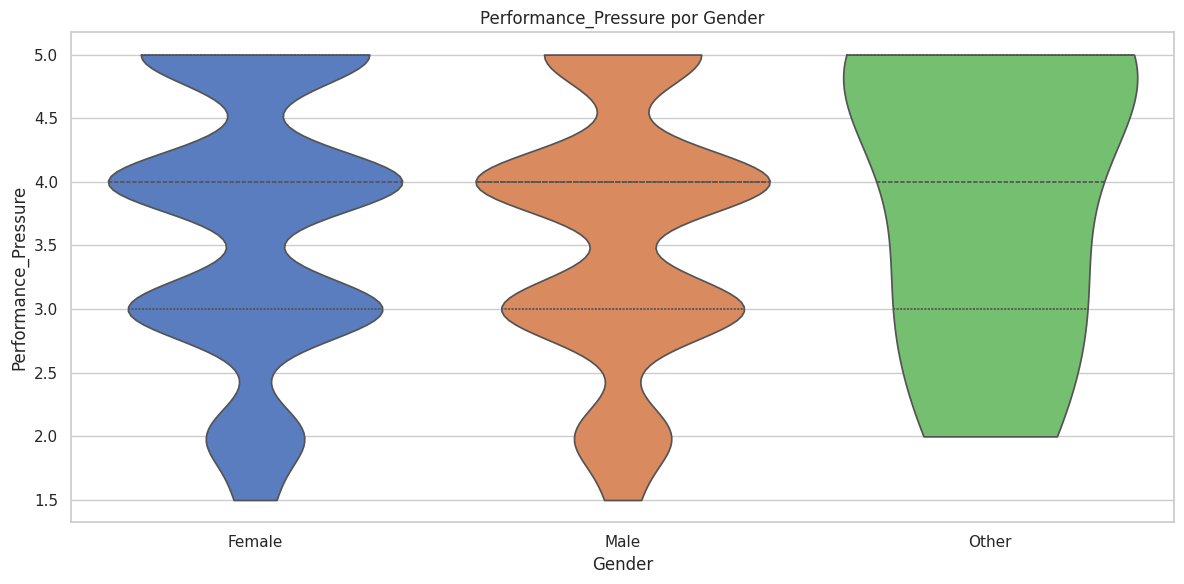

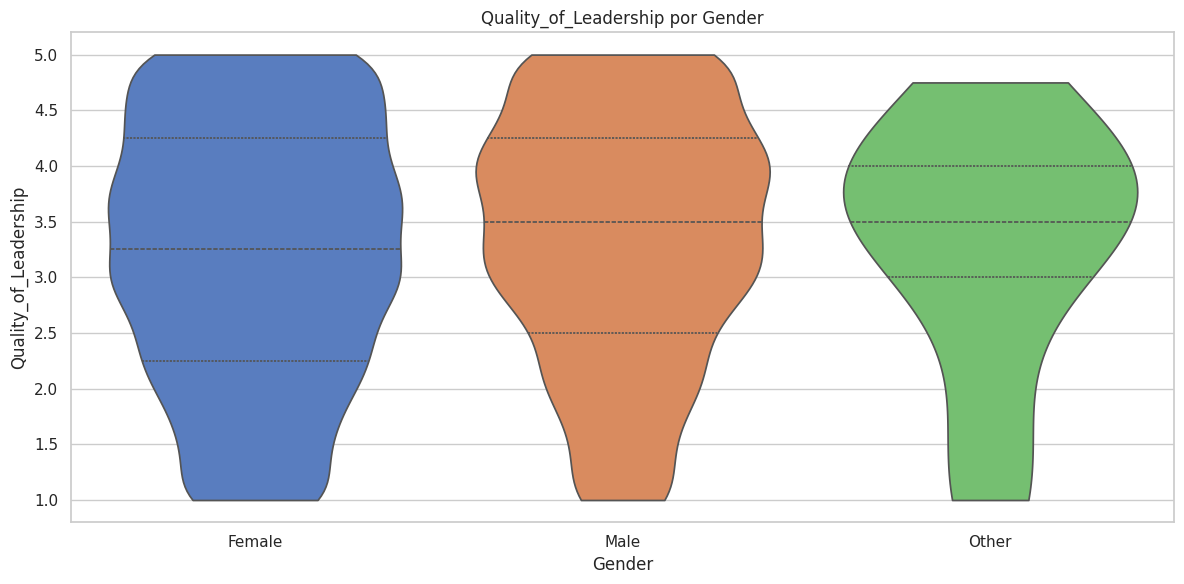

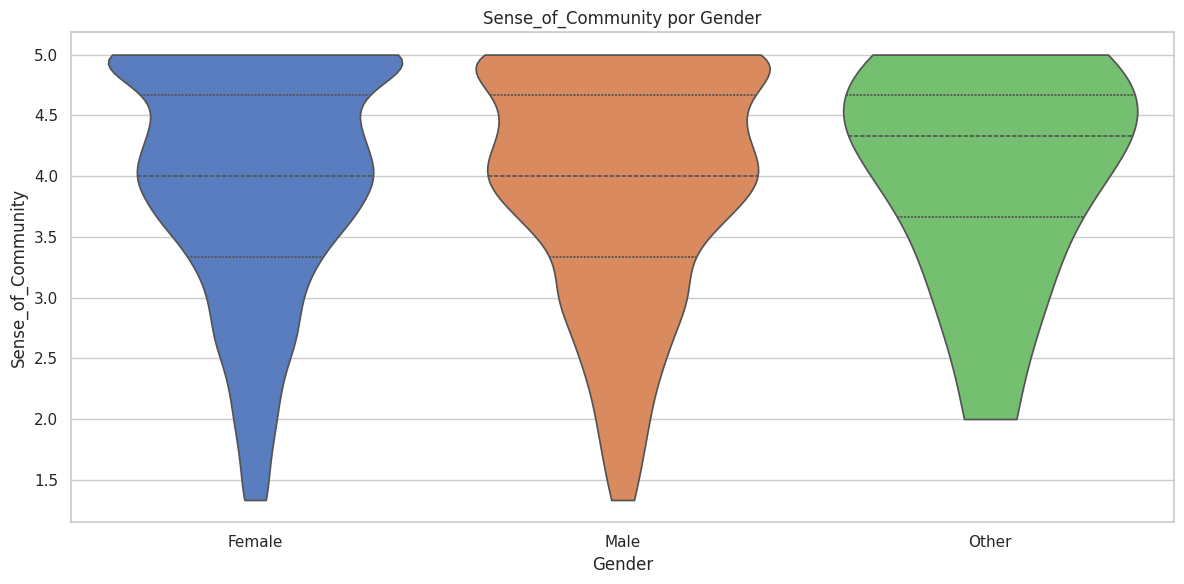

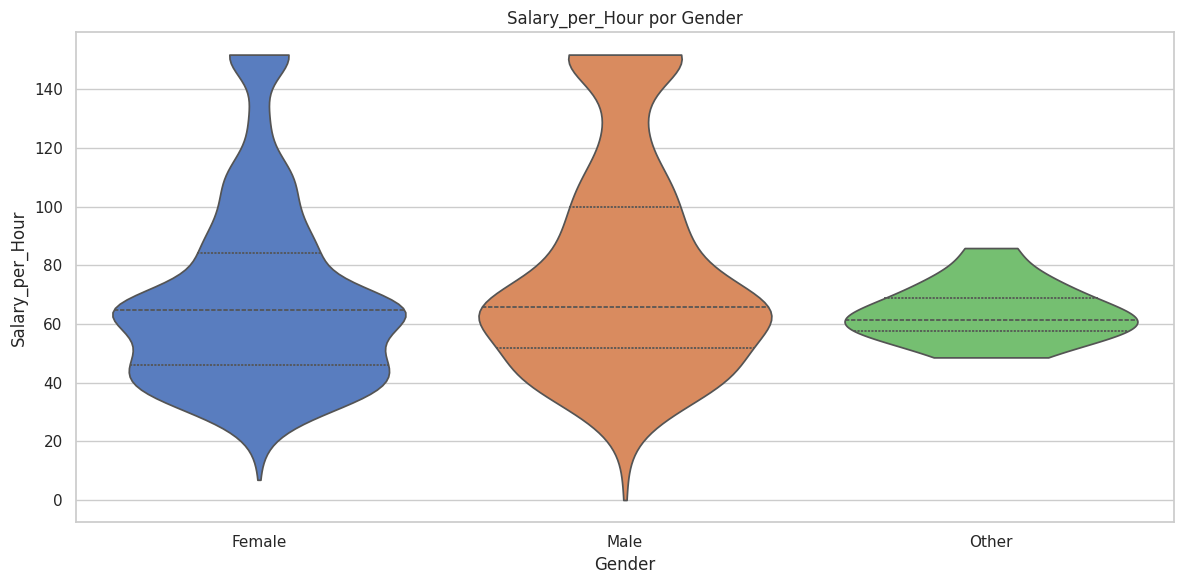

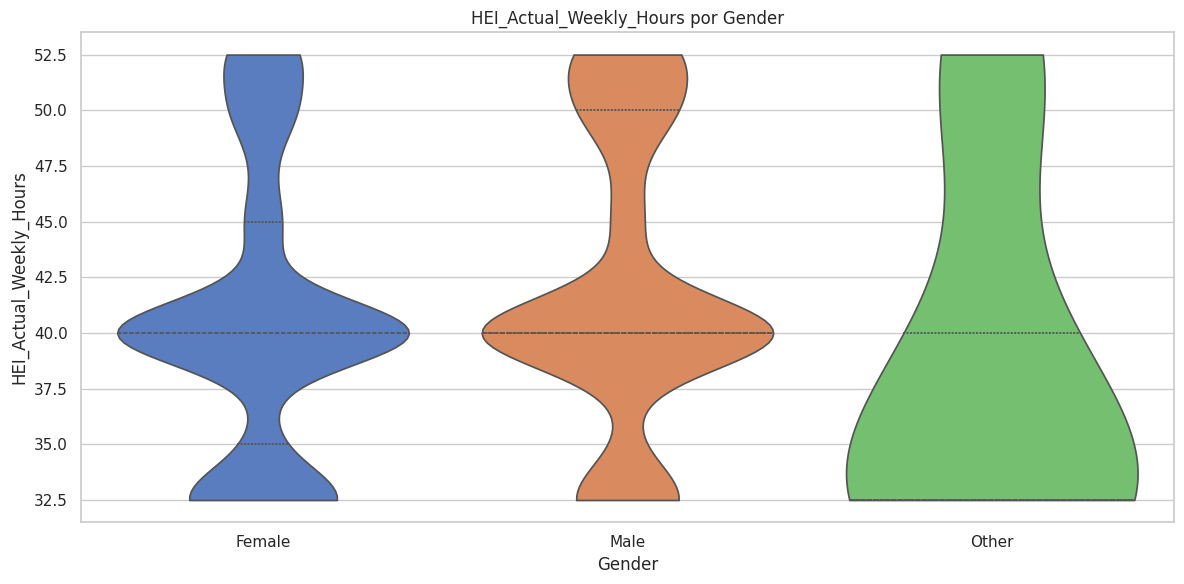

#### Análisis Agrupado por: HEI_Type

Job_Satisfaction          Burnout        Perceived_Autonomy  \
                        mean median      mean median               mean   
HEI_Type                                                                  
Private HEI         3.080000    3.0  3.150000   3.50           3.477778   
Public HEI          3.248254    3.2  4.286093   4.00           3.231684   
State HEI           3.308491    3.4  3.307075   3.25           3.072327   

                      Performance_Pressure        Quality_of_Leadership  \
               median                 mean median                  mean   
HEI_Type                                                                  
Private HEI  3.666667             3.433333    3.0              2.877778   
Public HEI   3.333333             3.650133    4.0              3.258685   
State HEI    3.166667             3.358491    3.0              3.290094   

                      Sense_of_Community        Salary_per_Hour             \
               median               mean median            mean     median   
HEI_Type                                                                     
Private HEI  2.666667           3.800000    4.0       51.323440  48.466922   
Public HEI   3.250000           3.935757    4.0       73.526925  64.826667   
State HEI    3.250000           3.948113    4.0       58.270401  55.390768   

            HEI_Actual_Weekly_Hours         
                               mean median  
HEI_Type                                    
Private HEI               38.000000   40.0  
Public HEI                41.224629   40.0  
State HEI                 41.066038   40.0

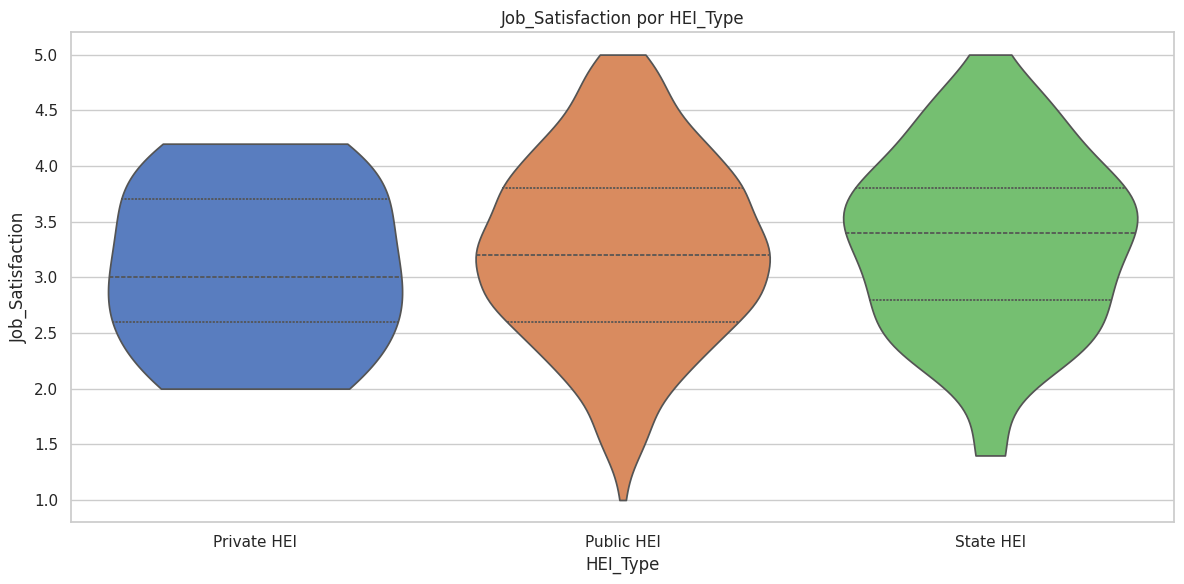

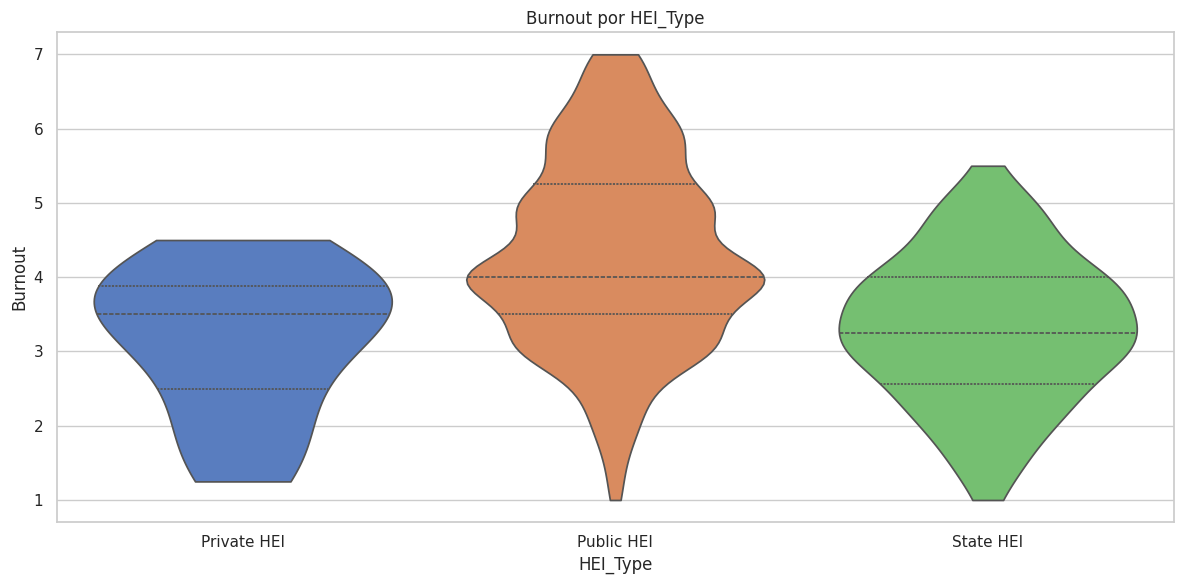

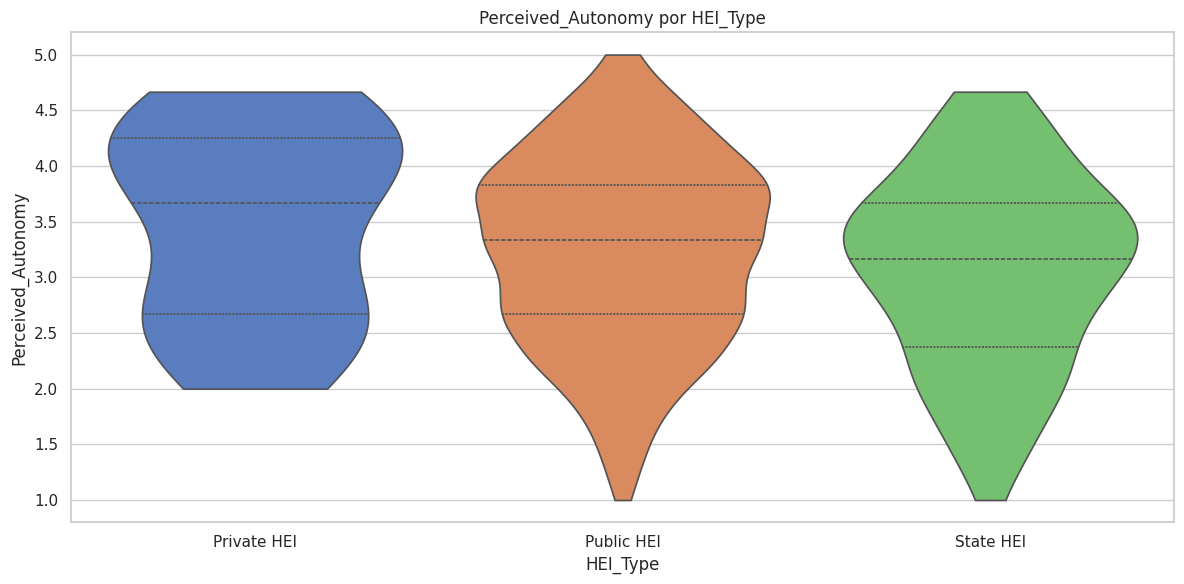

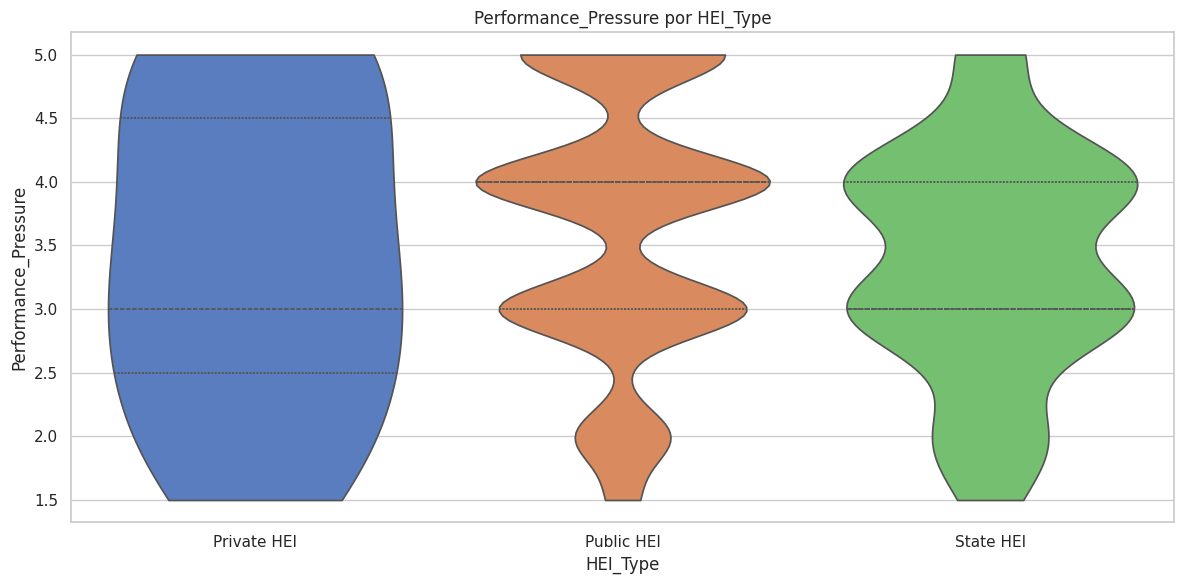

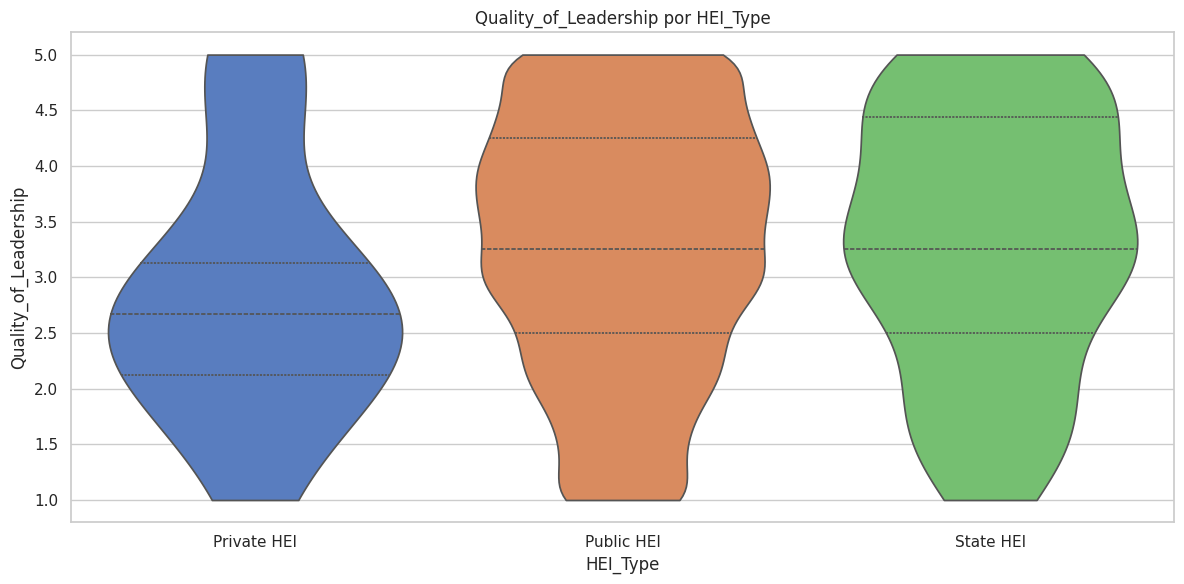

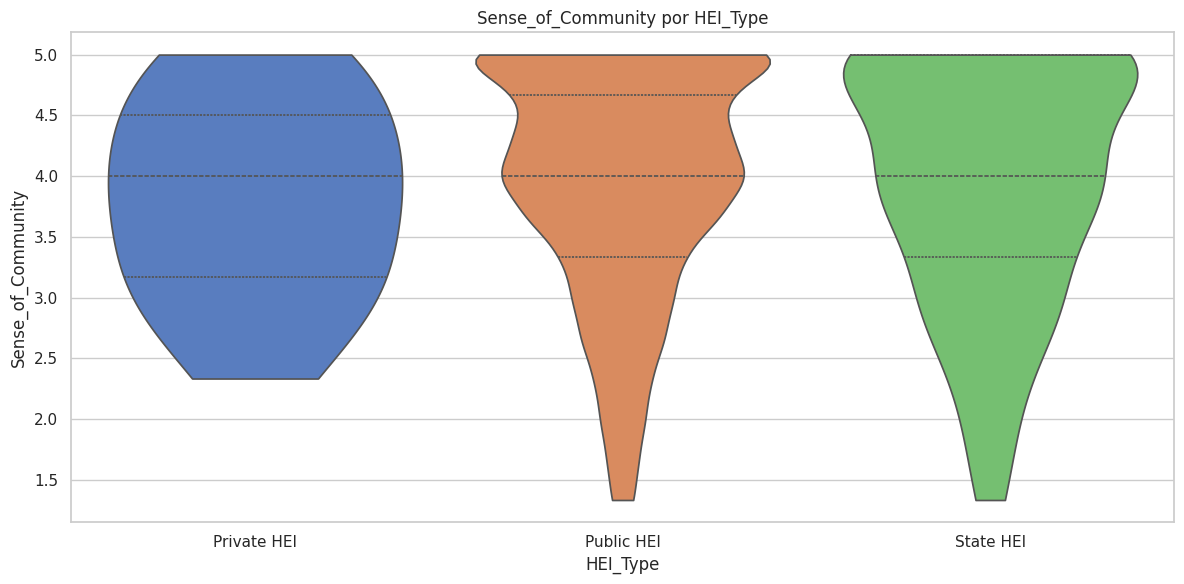

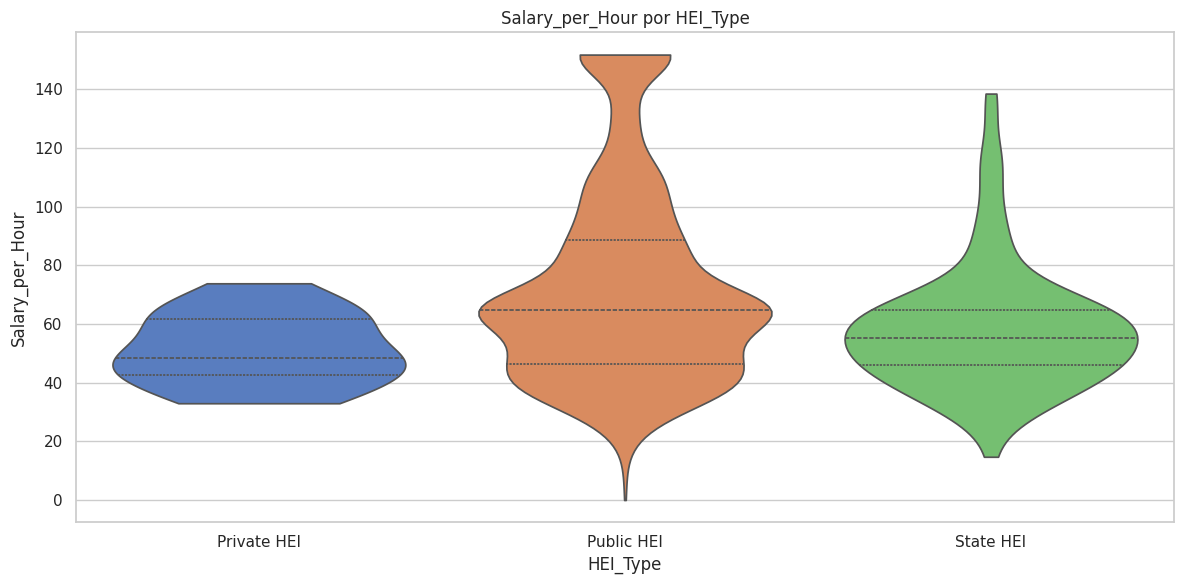

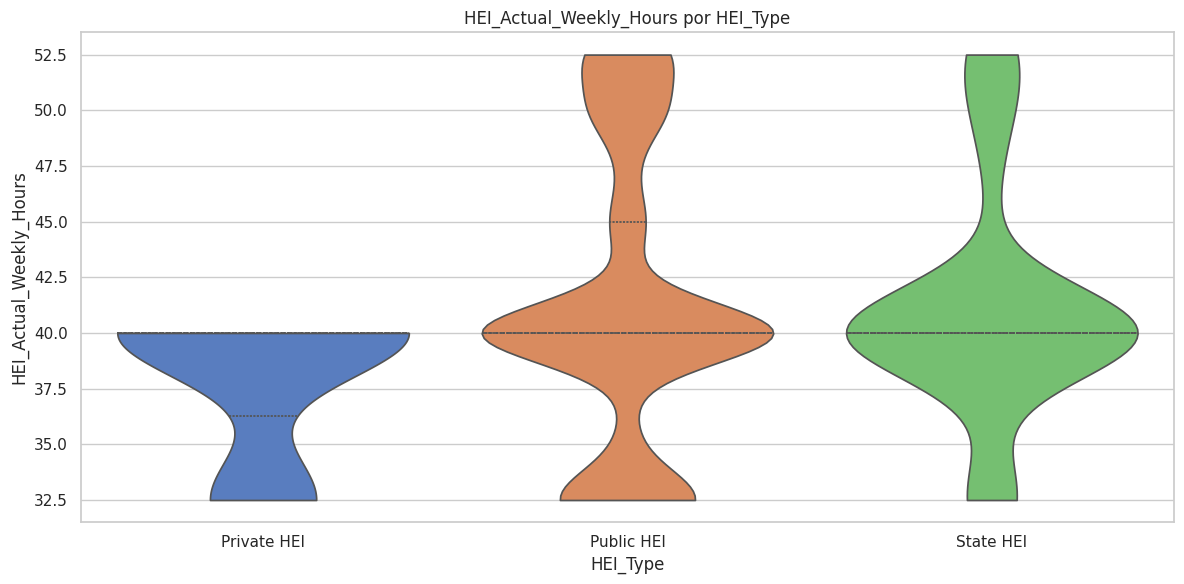

#### Análisis Agrupado por: Faculty_Subject_Area

Job_Satisfaction          Burnout         \
                                              mean median      mean median   
Faculty_Subject_Area                                                         
Agricultural/forestry/veterinary          3.173469    3.2  4.214286   4.00   
Culture/art                               3.282716    3.2  4.491015   4.25   
Economic sciences                         3.429620    3.4  4.056962   4.00   
Healthcare/medical/pharmaceutical         3.219057    3.2  4.101093   4.00   
Humanities/social sciences                3.195895    3.2  4.342014   4.25   
Law                                       3.296296    3.4  4.115741   4.25   
Natural sciences                          3.241488    3.2  4.170338   4.00   
Other_Faculty                             3.275000    3.4  3.750000   3.75   
Pedagogy/teacher training                 3.318605    3.2  4.300000   4.00   
Sport sciences                            3.304348    3.2  4.097826   3.75   
Technical sciences                        3.198110    3.2  4.257045   4.00   
Unspecified/cannot be categorised         3.372368    3.4  4.036732   4.00   

                                  Perceived_Autonomy            \
                                                mean    median   
Faculty_Subject_Area                                             
Agricultural/forestry/veterinary            3.126531  3.333333   
Culture/art                                 3.402743  3.500000   
Economic sciences                           3.297257  3.250000   
Healthcare/medical/pharmaceutical           3.155191  3.333333   
Humanities/social sciences                  3.201839  3.300000   
Law                                         3.364198  3.500000   
Natural sciences                            3.231774  3.333333   
Other_Faculty                               2.604762  2.416667   
Pedagogy/teacher training                   3.269612  3.166667   
Sport sciences                              3.427536  3.666667   
Technical sciences                          3.132188  3.166667   
Unspecified/cannot be categorised           3.257237  3.333333   

                                  Performance_Pressure         \
                                                  mean median   
Faculty_Subject_Area                                            
Agricultural/forestry/veterinary              3.785714    4.0   
Culture/art                                   3.283951    3.0   
Economic sciences                             3.854430    4.0   
Healthcare/medical/pharmaceutical             3.692623    4.0   
Humanities/social sciences                    3.720592    4.0   
Law                                           3.592593    4.0   
Natural sciences                              3.730799    4.0   
Other_Faculty                                 3.500000    4.0   
Pedagogy/teacher training                     3.493023    3.0   
Sport sciences                                3.260870    3.0   
Technical sciences                            3.697595    4.0   
Unspecified/cannot be categorised             3.250658    3.0   

                                  Quality_of_Leadership         \
                                                   mean median   
Faculty_Subject_Area                                             
Agricultural/forestry/veterinary               2.867857  3.000   
Culture/art                                    3.354390  3.500   
Economic sciences                              3.484177  3.500   
Healthcare/medical/pharmaceutical              3.126708  3.250   
Humanities/social sciences                     3.249170  3.250   
Law                                            3.152778  3.250   
Natural sciences                               3.238044  3.250   
Other_Faculty                                  3.357143  3.500   
Pedagogy/teacher training                      3.418217  3.500   
Sport sciences                                 3.326087  3.500   
Technical sciences                    

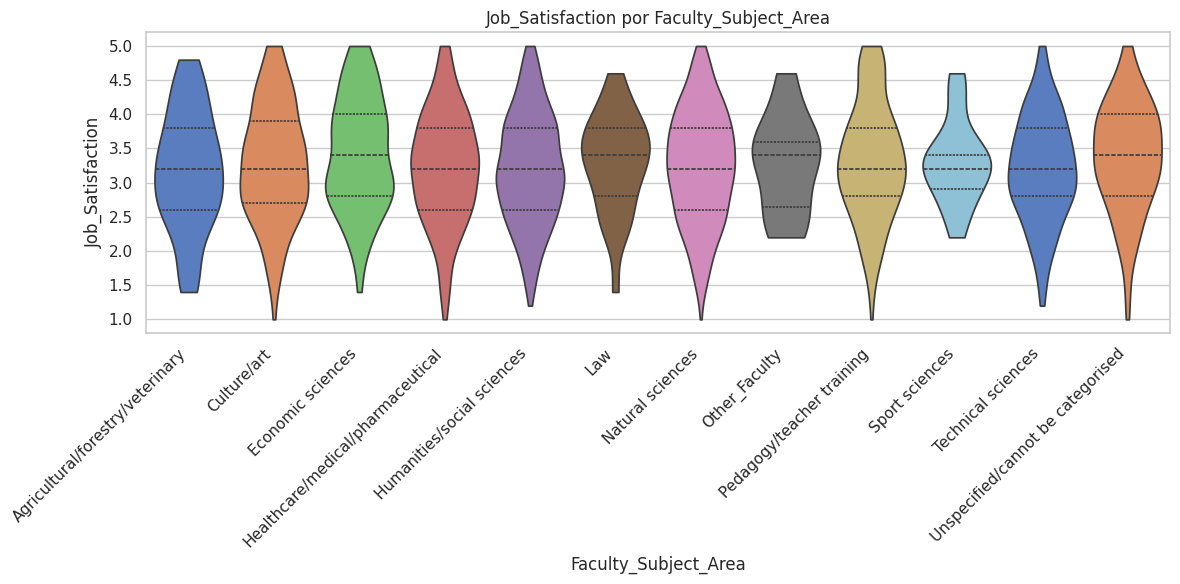

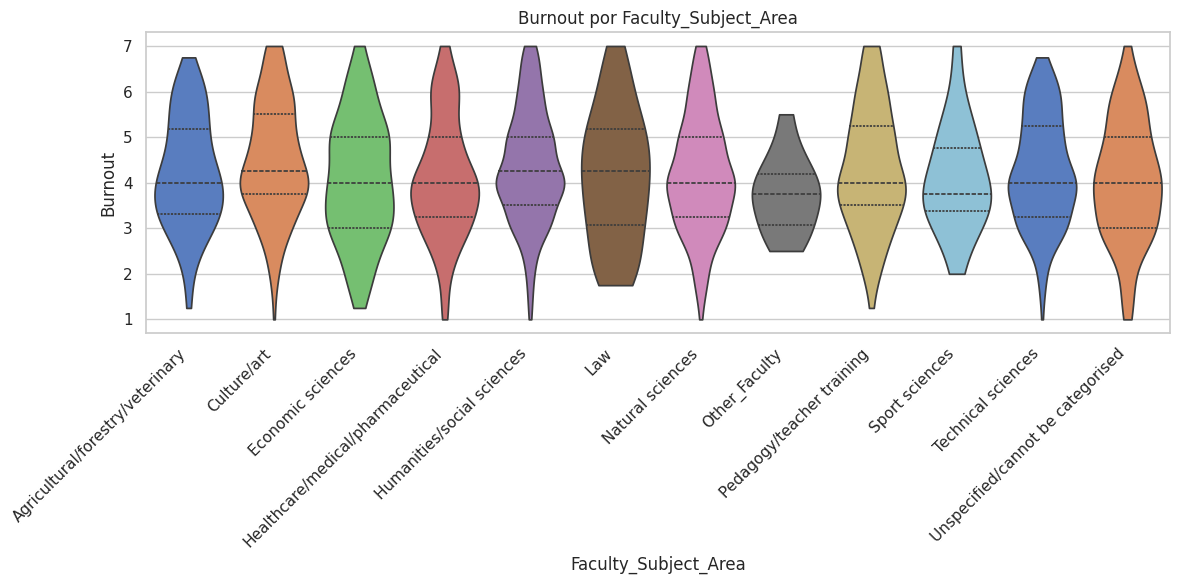

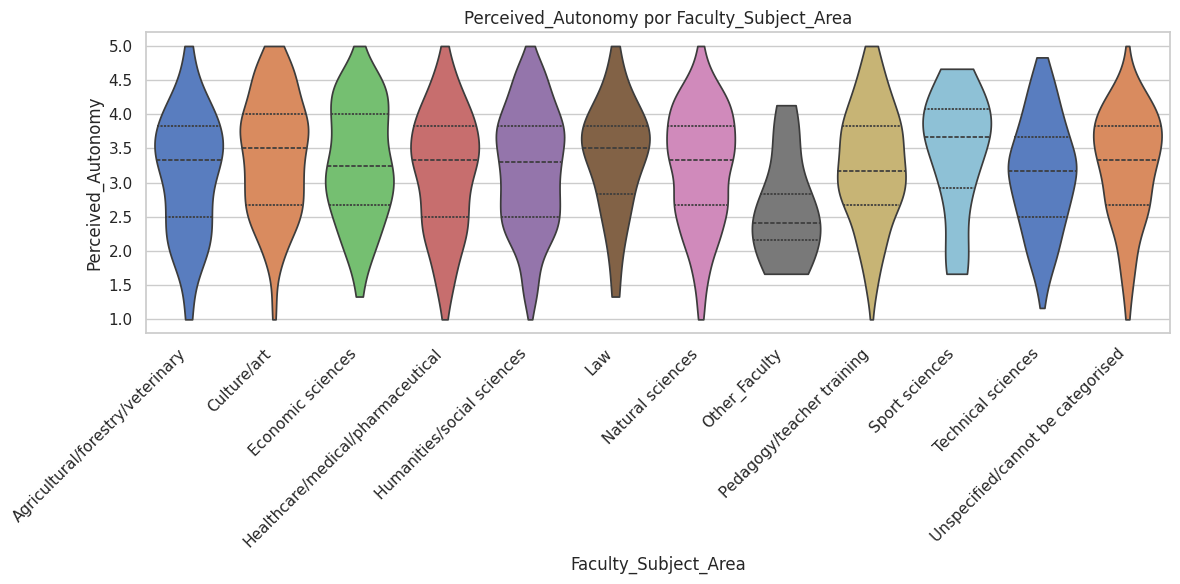

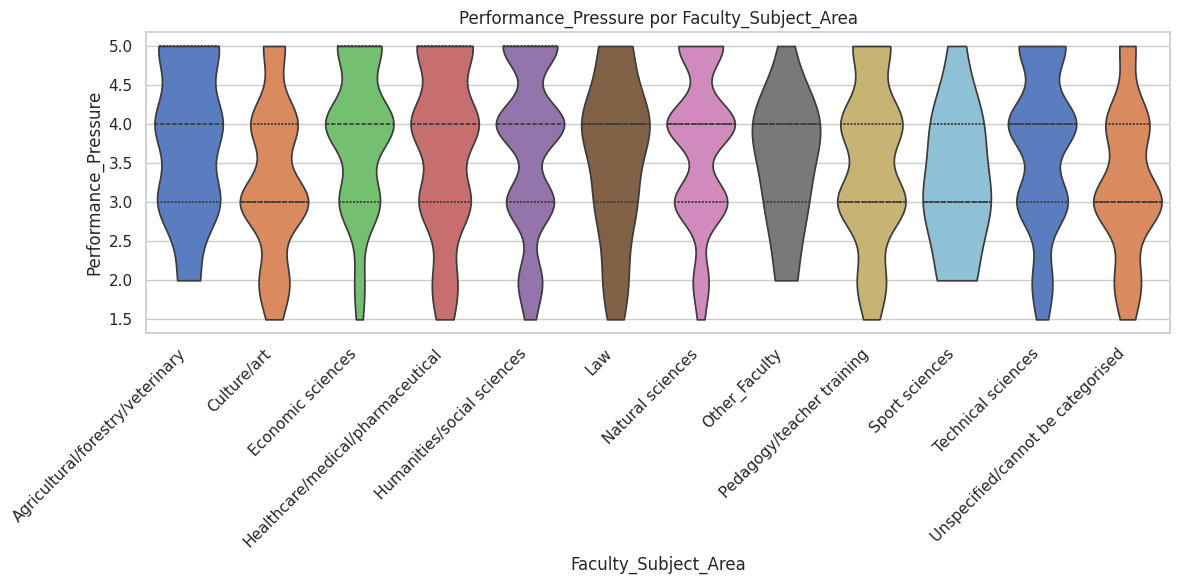

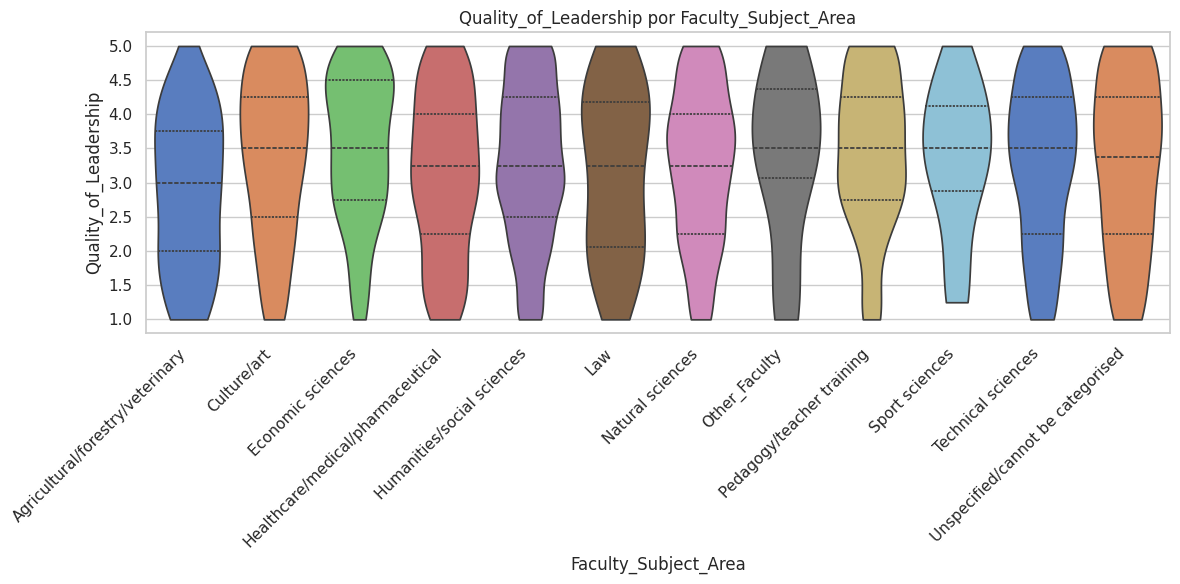

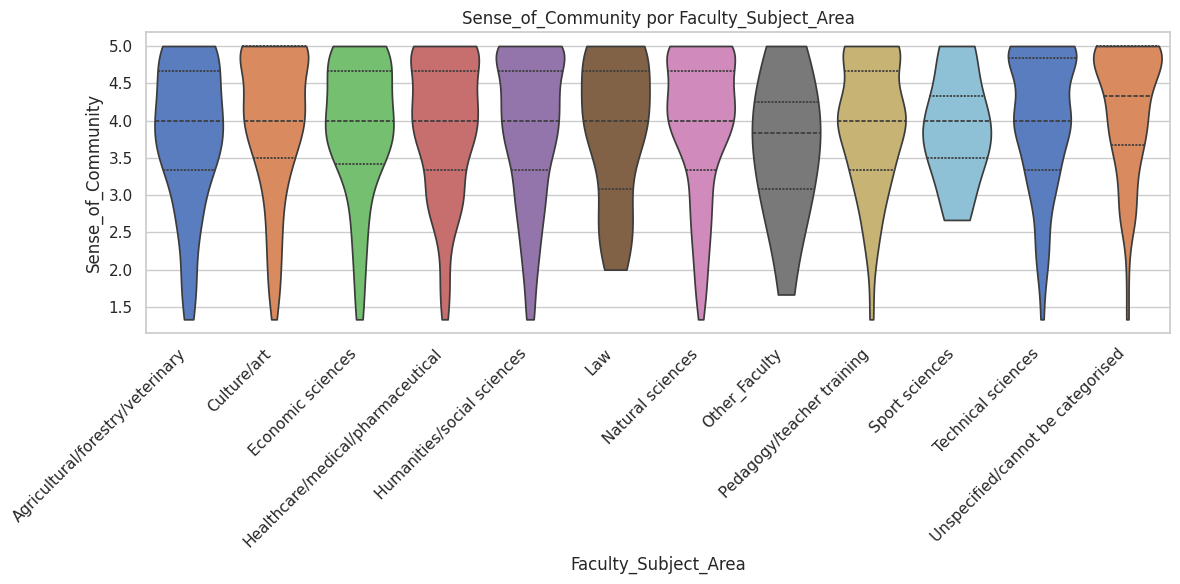

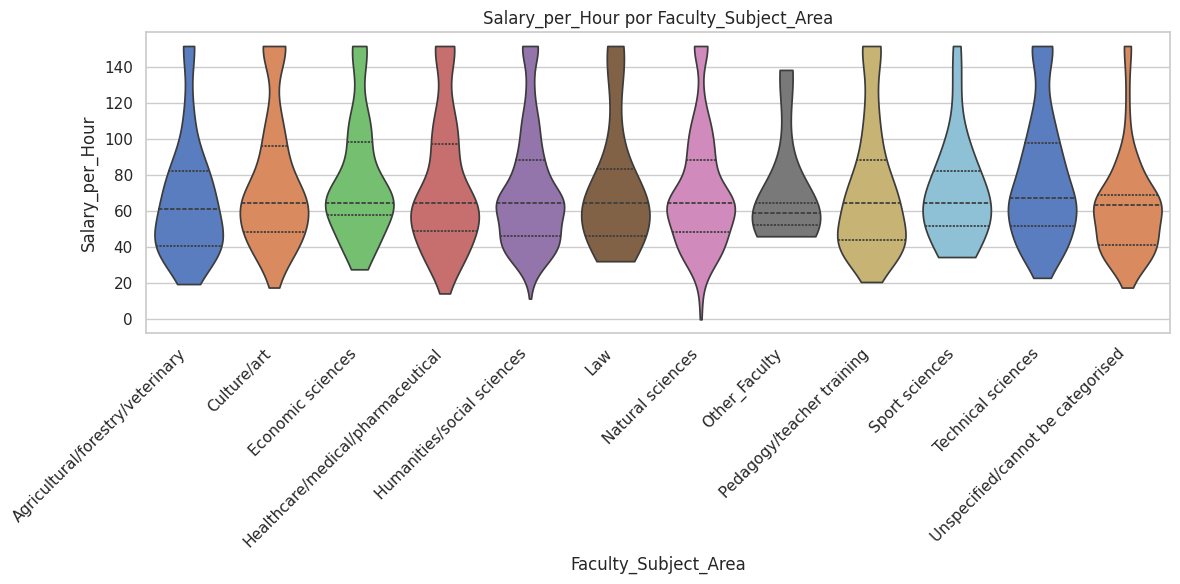

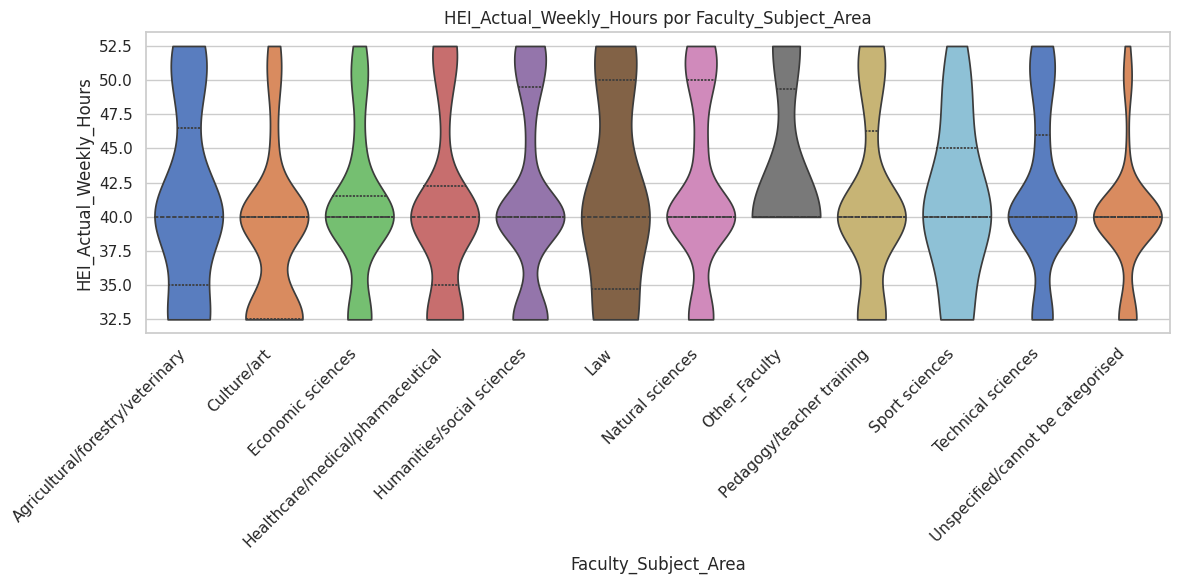

#### Análisis Agrupado por: Age_Group

Job_Satisfaction          Burnout        Perceived_Autonomy  \
                      mean median      mean median               mean   
Age_Group                                                               
<30               3.257249    3.2  4.336084  4.250           3.288457   
30-39             3.151497    3.2  4.324454  4.250           3.208859   
40-49             3.186230    3.2  4.136092  4.000           3.112267   
50-59             3.350688    3.4  4.315979  4.000           3.294630   
60+               3.645047    3.8  4.055031  3.875           3.527830   

                    Performance_Pressure        Quality_of_Leadership         \
             median                 mean median                  mean median   
Age_Group                                                                      
<30        3.333333             3.577994    4.0              3.526861   3.75   
30-39      3.333333             3.625364    4.0              3.261731   3.25   
40-49      3.166667             3.662528    4.0              3.151957   3.25   
50-59      3.333333             3.633988    4.0              3.211100   3.25   
60+        3.666667             3.676887    4.0              3.409041   3.50   

          Sense_of_Community           Salary_per_Hour             \
                        mean    median            mean     median   
Age_Group                                                           
<30                 4.139914  4.333333       62.530541  60.446275   
30-39               3.932443  4.000000       70.495793  64.826667   
40-49               3.834452  4.000000       71.040855  64.826667   
50-59               3.975769  4.000000       81.143254  64.826667   
60+                 3.978774  4.000000       84.334131  64.826667   

          HEI_Actual_Weekly_Hours         
                             mean median  
Age_Group                                 
<30                     39.589806   40.0  
30-39                   40.902306   40.0  
40-49                   41.413143   40.0  
50-59                   42.232809   40.0  
60+                     41.337264   40.0

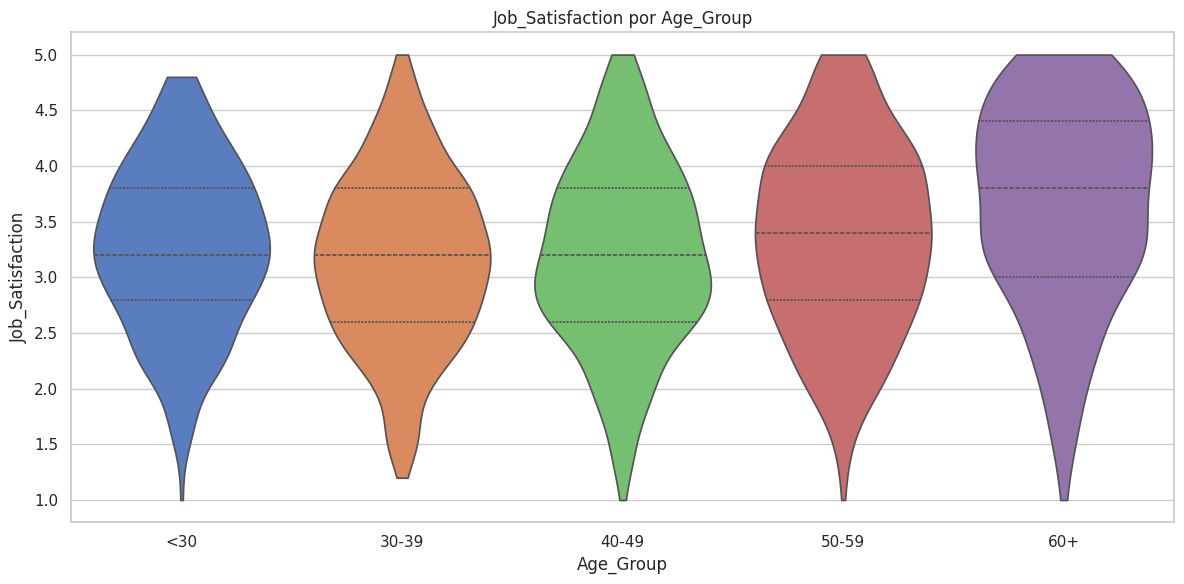

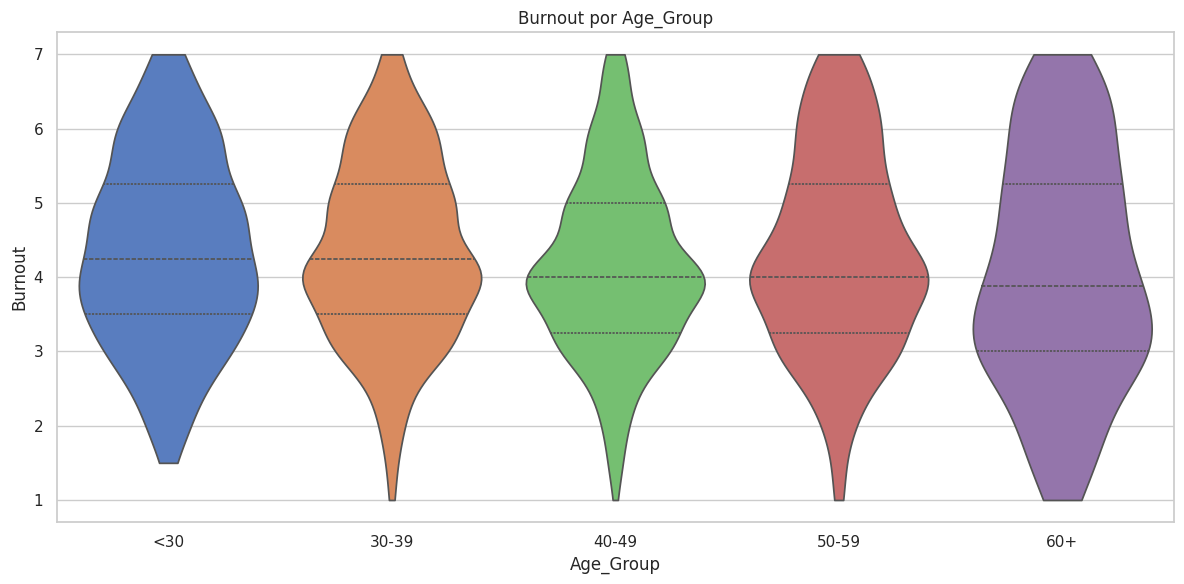

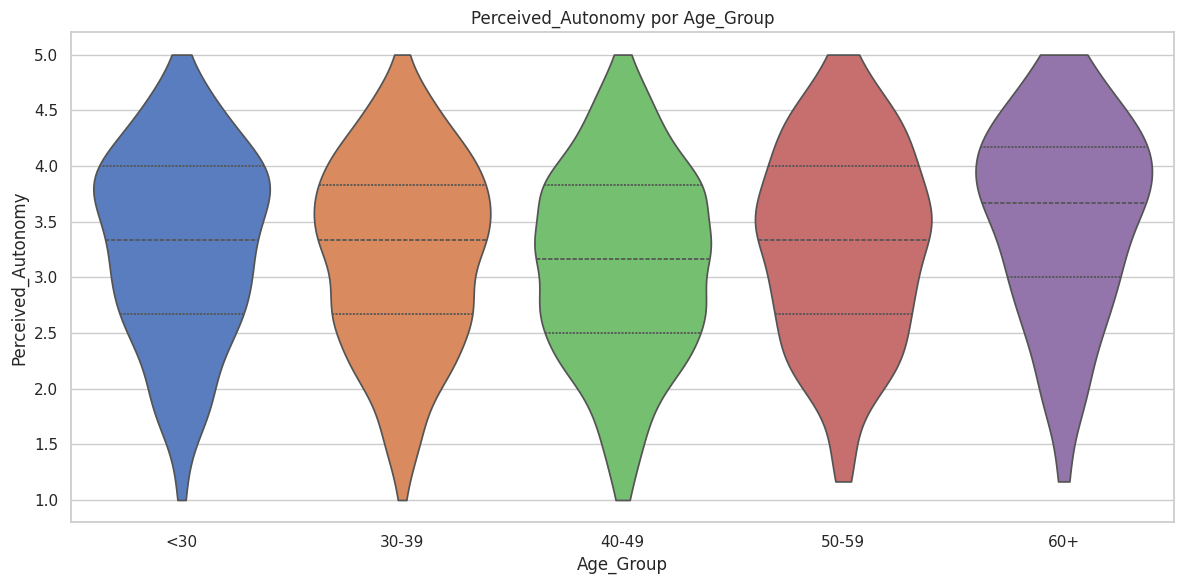

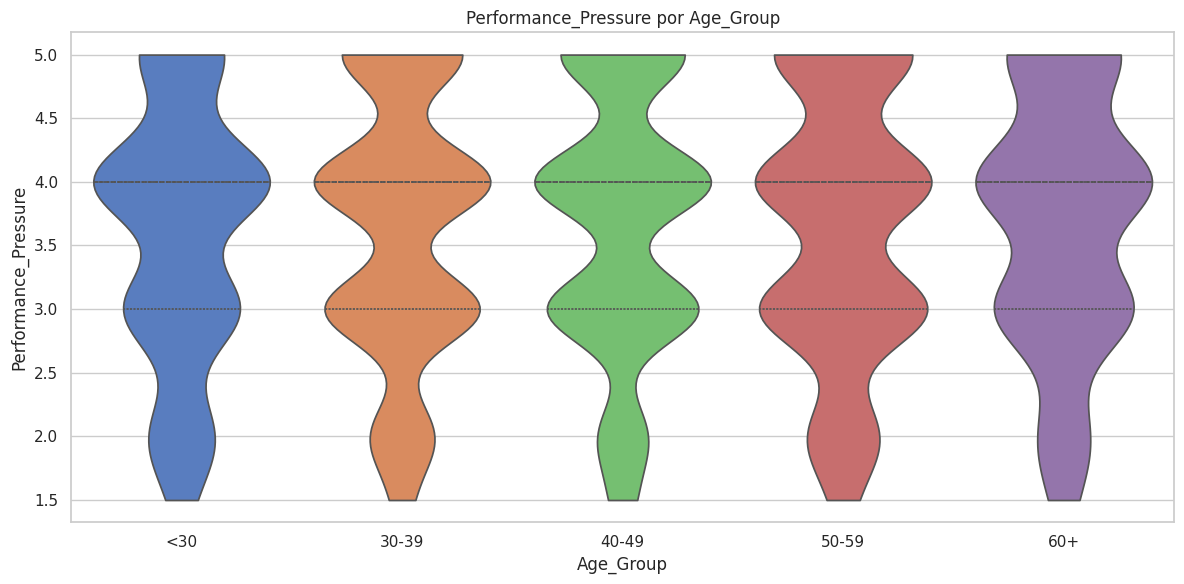

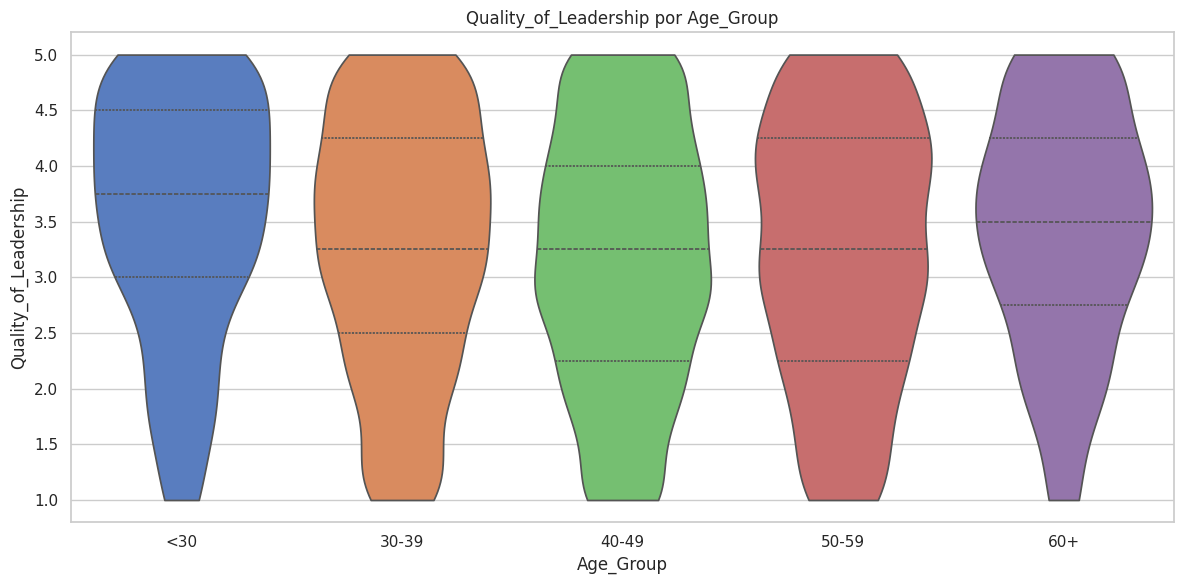

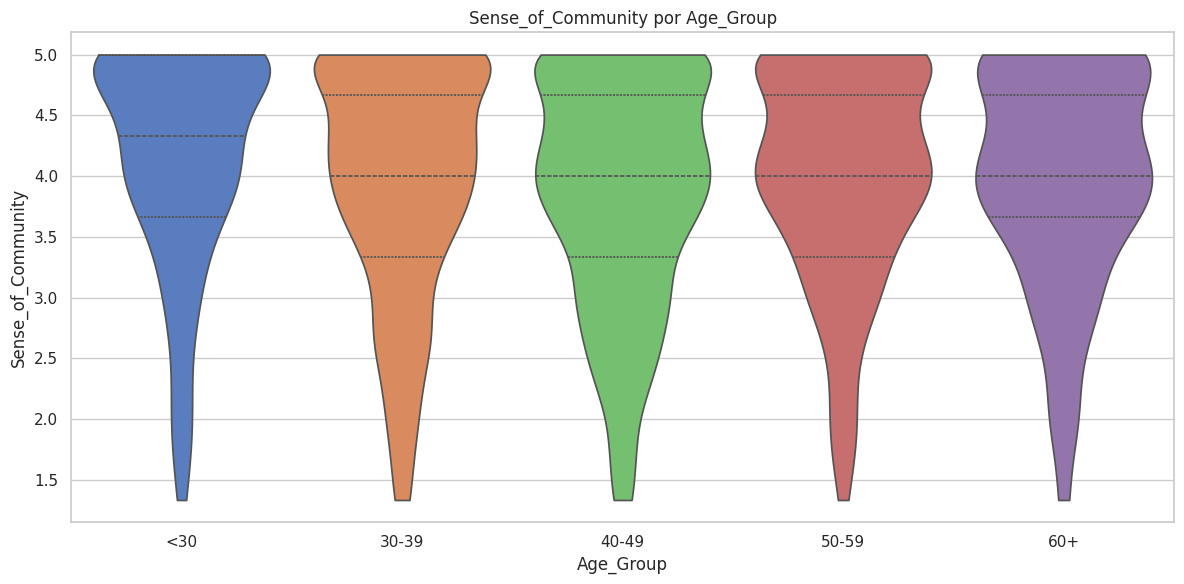

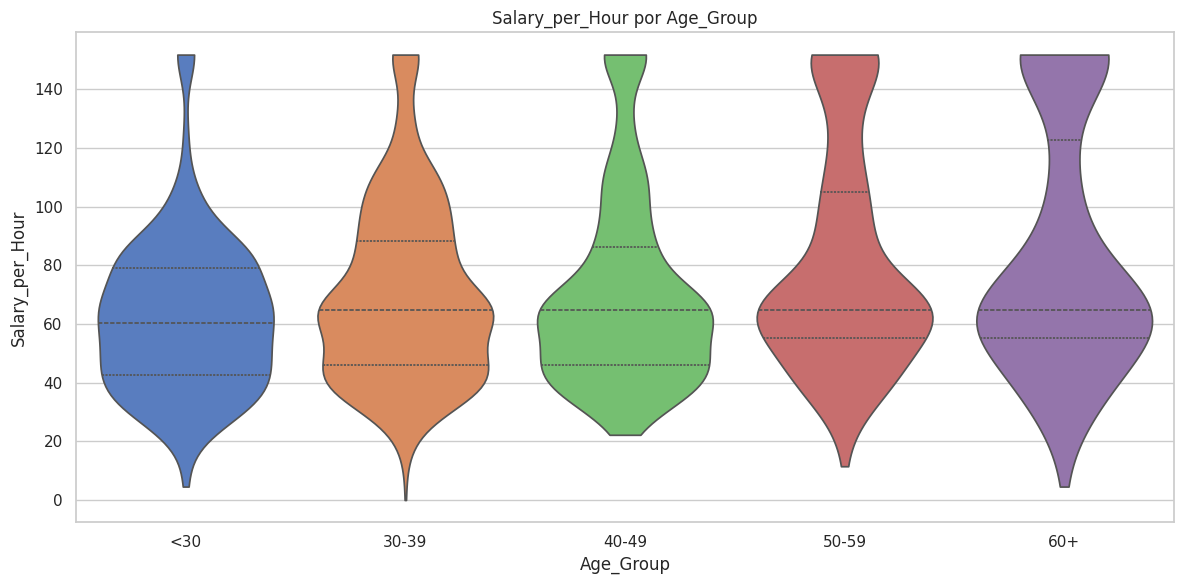

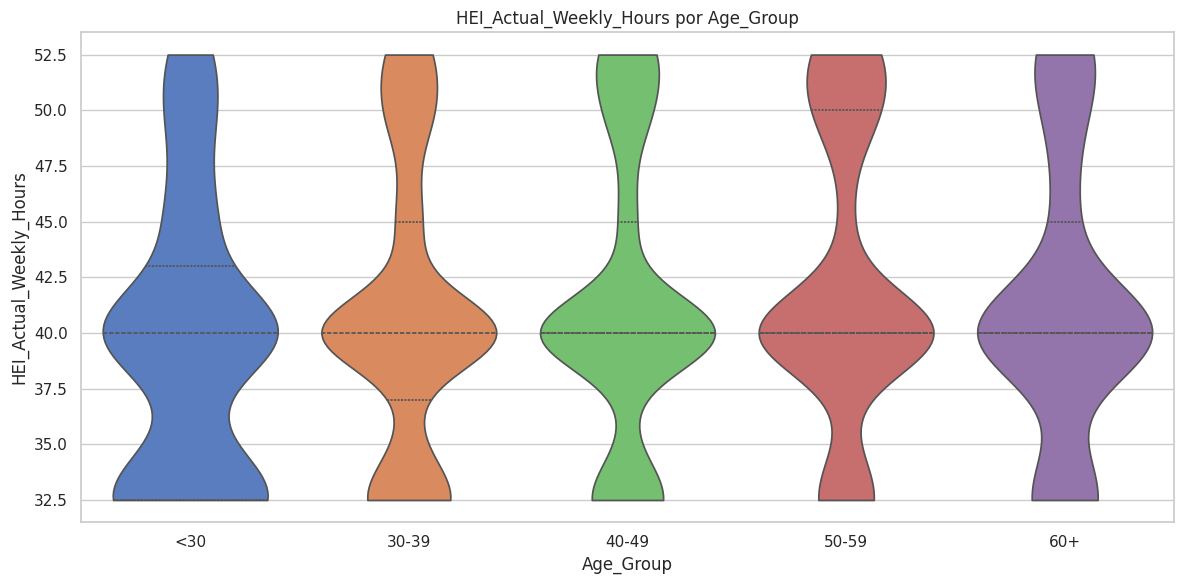

In [20]:
if not df_cleaned.empty and 'Age_Group' in df_cleaned.columns: # Asegurarse que Age_Group existe
    # --- Variables de Agrupación y Variables Objetivo ---
    grouping_vars = ['Country', 'Gender', 'HEI_Type', 'Faculty_Subject_Area', 'Age_Group']
    # Seleccionar variables de bienestar clave (asegúrate que existen y son numéricas)
    target_vars = [
        'Job_Satisfaction', 'Burnout', 'Perceived_Autonomy',
        'Performance_Pressure', 'Quality_of_Leadership', 'Sense_of_Community',
        # Añadir otras si son relevantes y numéricas, e.g.:
        'Salary_per_Hour', 'HEI_Actual_Weekly_Hours'
    ]

    # Filtrar target_vars para asegurar que existen en df_cleaned y son numéricas
    valid_target_vars = [var for var in target_vars if var in df_cleaned.columns and pd.api.types.is_numeric_dtype(df_cleaned[var])]
    print(f"Variables de bienestar a analizar: {valid_target_vars}")

    # --- Generar Estadísticas Agrupadas y Gráficos ---
    for group_var in grouping_vars:
        if group_var in df_cleaned.columns:
            display(Markdown(f"#### Análisis Agrupado por: {group_var}"))

            # Calcular estadísticas descriptivas agrupadas (media y mediana)
            grouped_stats = df_cleaned.groupby(group_var)[valid_target_vars].agg(['mean', 'median'])
            display(grouped_stats)

            # Generar gráficos comparativos (Boxplots o Violinplots)
            for target_var in valid_target_vars:
                plt.figure(figsize=(12, 6))
                # Usar violinplot para mostrar distribución además de comparación
                sns.violinplot(x=group_var, y=target_var, data=df_cleaned, palette='muted', cut=0, inner='quartile')
                # Alternativa: sns.boxplot(x=group_var, y=target_var, data=df_cleaned, palette='muted')

                plt.title(f'{target_var} por {group_var}')
                plt.xlabel(group_var)
                plt.ylabel(target_var)
                # Rotar etiquetas del eje X si son muchas o largas
                if df_cleaned[group_var].nunique() > 5:
                    plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                plt.show()
        else:
             print(f"Advertencia: La variable de agrupación '{group_var}' no se encontró en el DataFrame.")

else:
    print("DataFrame vacío o 'Age_Group' no creado, análisis agrupado omitido.")

## 6. Conclusiones Preliminares del EDA y Próximos Pasos

El análisis exploratorio ha proporcionado una visión detallada de las características del conjunto de datos y ha revelado patrones iniciales y posibles disparidades en el bienestar laboral.

**Observaciones Clave:**
* Se han identificado las distribuciones de las variables numéricas y categóricas.
* El análisis de correlación muestra algunas relaciones lineales entre variables numéricas, pero también indica la necesidad de modelos más complejos para capturar relaciones no lineales.
* El análisis agrupado ha comenzado a señalar diferencias en las percepciones de bienestar según el país, género, edad, tipo de institución y área de estudio. Estas diferencias merecen una investigación más profunda mediante pruebas estadísticas (e.g., t-tests, ANOVA) y modelado multivariado.

**Próximos Pasos:**
1.  **Análisis Estadístico Inferencial:** Realizar pruebas de hipótesis para confirmar si las diferencias observadas en el análisis agrupado son estadísticamente significativas.
2.  **Selección de Variables:** Basándose en el EDA y la teoría, seleccionar las variables predictoras y dependientes más relevantes para el modelado.
3.  **Modelado:** Desarrollar modelos (e.g., regresión lineal múltiple, regresión logística/ordinal, modelos de ecuaciones estructurales) para identificar los determinantes clave del bienestar laboral, controlando por múltiples factores.
4.  **Codificación para Modelos:** Para el modelado, las variables categóricas con etiquetas de texto deberán ser codificadas numéricamente (e.g., one-hot encoding, label encoding).
5.  **Escalado:** Las variables numéricas probablemente necesitarán ser escaladas (e.g., estandarización) antes de aplicar ciertos algoritmos de modelado.